In [1]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.stats import chisquare
from statsmodels.stats.multitest import multipletests
from matplotlib.backends.backend_pdf import PdfPages
import PyComplexHeatmap as pch
import os
import decoupler as dc
from adjustText import adjust_text


tissue_dict = {
    'CortexHippocampus': '#F8C471',  
    'Heart': '#AF7AC5',             
    'Liver': '#F15922',               
    'DiencephalonPituitary': '#27AE60',  
    'Adrenal': '#8B4513',        
    'Kidney': '#CF1E1A',              
    'Gastrocnemius': '#FF69B4',        
    'GonadsFemale': '#2FE3E5',       
    'GonadsMale': '#00B7B8'     
}


geno_dict = {
    '129S1J': '#DA9CC1',  
    'AJ': '#F4C245',             
    'B6J': '#C0BFBF',               
    'CASTJ': '#55AF5B',  
    'NODJ': '#4F6EAF',        
    'NZOJ': '#52A5DB',              
    'PWKJ': '#D83026',        
    'WSBJ': '#683C91'   
}

strain_dict = {'Lab': 'darkgrey', 'Wild': '#d3a021'}


# Fig. S5a

In [2]:
def process_degs_data(tissue, lfc_cutoff=1, padj_cutoff=0.05):
    df_genes = pd.read_csv(f"/share/crsp/lab/seyedam/share/igvf_pipeline/figures/degs/{tissue}/results_de_analysis.csv", index_col=0)
    df_genes.reset_index(inplace=True)  
    df_genes = df_genes[df_genes['log2FoldChange'].abs() >= lfc_cutoff]
    df_genes = df_genes[df_genes['padj'] <= padj_cutoff]
    df_genes[['Genotype1', 'Genotype2']] = df_genes['comparison'].str.replace('Genotype_', '').str.split('_vs_', expand=True)
    return df_genes

In [3]:
tissues = [
    'Gastrocnemius', 'Heart', 'Adrenal', 'Kidney', 
    'Liver', 'CortexHippocampus', 'GonadsMale', 
    'GonadsFemale', 'DiencephalonPituitary'
]

tissue_palette = sns.color_palette("tab10", len(tissues))
tissue_colors = dict(zip(tissues, tissue_palette))

# Create a dictionary to store plot data for each tissue
all_plot_data = {}

for tissue in tissues:
    try:
        print(f"Processing tissue: {tissue}")
        
        # Process degs data
        degs = process_degs_data(tissue)

        # Load pseudobulk data
        pdata = sc.read_h5ad(f"/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/pseudobulk/{tissue}_pseudobulk.h5ad")
        #norm_counts = sc.pp.normalize_total(pdata, target_sum=1e6,  inplace = False)['X'] # layer = 'cellbender_counts',

        #pdata.layers['norm_counts'] = norm_counts

        pdata2 = dc.pp.pseudobulk(
            pdata, 
            sample_col="subtype", 
            groups_col=None,
            #layer='cellbender_counts',
            mode='mean', 
            skip_checks=True, 
        )
        expr_df = pdata2.to_df().transpose()
        #median_threshold = expr_df.median().median()
        #print(median_threshold)

        # Load metadata
        obs = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
        obs = obs[obs['subtype'] != 'low quality']
        total_cells = obs.shape[0]
        subtype_proportions = obs['subtype'].value_counts() / total_cells

        # Calculate unique genes and expressed genes
        unique_gene_counts = degs.groupby('celltype')['gene_name'].nunique()
        expressed_gene_counts = (expr_df > 0.1).sum(axis=0)

        # Combine into a DataFrame
        plot_data = pd.DataFrame({
            'unique_genes': unique_gene_counts,
            'expressed_genes': expressed_gene_counts
        }).reset_index()

        # Drop NaN values and add proportions and tissue
        plot_data = plot_data.dropna(subset=['unique_genes'])
        plot_data['proportion'] = plot_data['index'].map(subtype_proportions)
        plot_data['scaled_size'] = plot_data['proportion'] * 1000  # Adjust multiplier if needed
        plot_data['tissue'] = tissue

        # Save plot_data for the tissue
        all_plot_data[tissue] = plot_data

    except Exception as e:
        print(f"An error occurred for tissue {tissue}: {e}")


Processing tissue: Gastrocnemius


/tmp/ipykernel_2994637/4024728880.py:39: DtypeWarning: Columns (49) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')


Processing tissue: Heart


/tmp/ipykernel_2994637/4024728880.py:39: DtypeWarning: Columns (27,33) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')


Processing tissue: Adrenal
Processing tissue: Kidney


...

/tmp/ipykernel_2994637/4024728880.py:39: DtypeWarning: Columns (24,25,35) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')


Processing tissue: CortexHippocampus


/tmp/ipykernel_2994637/4024728880.py:39: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')


Processing tissue: GonadsMale
Processing tissue: GonadsFemale
Processing tissue: DiencephalonPituitary


/tmp/ipykernel_2994637/4024728880.py:39: DtypeWarning: Columns (24,27,28,29,30,33) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')


In [4]:
combined_plot_data = pd.concat(all_plot_data.values(), ignore_index=True)


/tmp/ipykernel_2994637/3449226145.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['unique_genes'].corr(x['proportion_pct']))


Average Pearson r: 0.862576426908868


2025-07-10 20:05:12 | [WARNING] Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


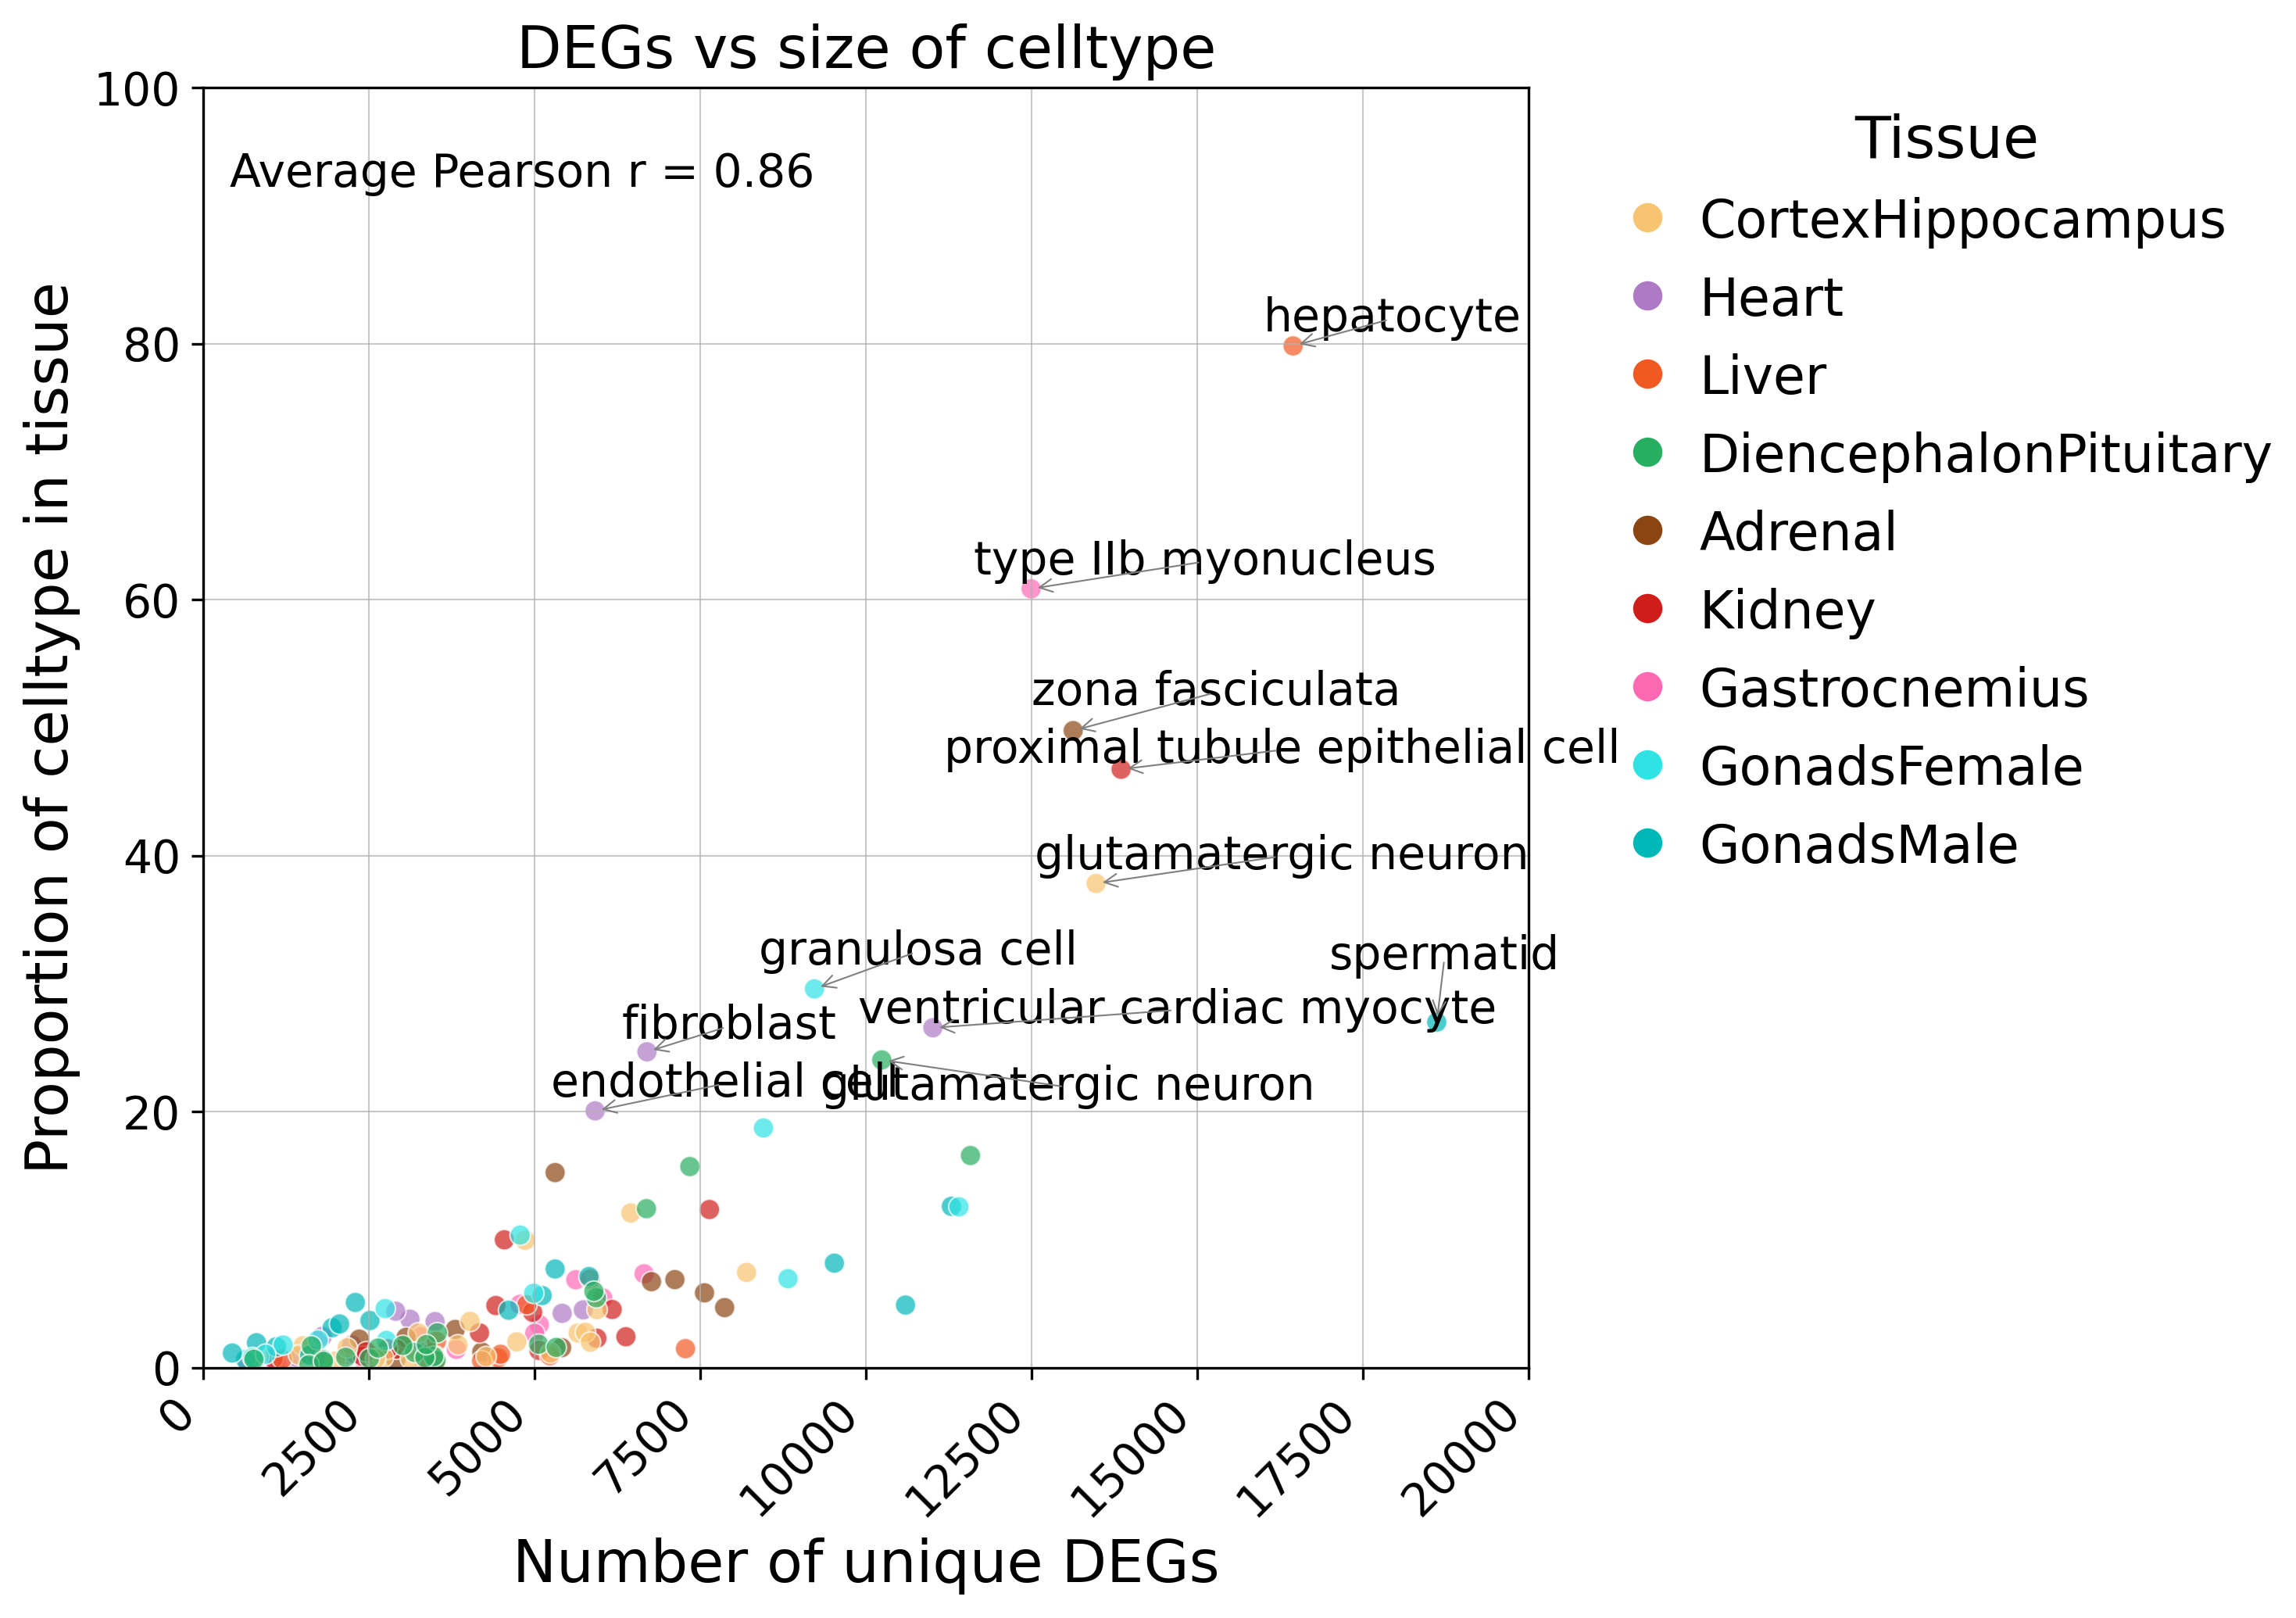

In [5]:
tissue_dict = {
    'CortexHippocampus': '#F8C471',  
    'Heart': '#AF7AC5',             
    'Liver': '#F15922',               
    'DiencephalonPituitary': '#27AE60',  
    'Adrenal': '#8B4513',        
    'Kidney': '#CF1E1A',              
    'Gastrocnemius': '#FF69B4',        
    'GonadsFemale': '#2FE3E5',       
    'GonadsMale': '#00B7B8'     
}


plt.figure(figsize=(10, 7), dpi=300)  # Increase DPI to 300 for higher resolution

combined_plot_data['proportion_pct'] = combined_plot_data['proportion'] * 100

correlations = (
    combined_plot_data.groupby('tissue')
    .apply(lambda x: x['unique_genes'].corr(x['proportion_pct']))
    .reset_index(name='pearson_r')
)
average_r = correlations['pearson_r'].mean()

print(f"Average Pearson r: {average_r}")


# Scatterplot with consistent point size based on scaled_size
sns.scatterplot(
    data=combined_plot_data,
    x='unique_genes',
    y='proportion_pct',
    hue='tissue',
    palette=tissue_dict,
    alpha=0.7,
    s=40
)

     
plt.xlim(0, 20000)  # Start x-axis at 0, no upper limit specified
plt.ylim(0, 100)  # Start y-axis at 0, no upper limit specified


texts = []
for _, row in combined_plot_data.iterrows():
    if row['unique_genes'] > 15000 or row['proportion_pct'] > 20:
        texts.append(
            plt.text(
                row['unique_genes'],
                row['proportion_pct'],
                row['index'],  # Label with the cell type or another identifier
                fontsize=14
            )
        )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.5),  # Optional: add arrows for clarity
    only_move={'points': 'xy', 'texts': 'xy'},  # Limit movement to within the plot
    force_text=0.5,  # Strength of text repulsion
    force_points=0.5,  # Strength of point repulsion
)


legend_handles = [
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=tissue)
    for tissue, color in tissue_dict.items()
]


plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title="Tissue",
    title_fontsize=18,
    fontsize=16
)



plt.grid(visible=True, which='both', linewidth=0.5, alpha=0.7)


plt.title("DEGs vs size of celltype", fontsize = 18)
plt.xlabel("Number of unique DEGs", fontsize = 18)
plt.ylabel("Proportion of celltype in tissue", fontsize = 18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45, ha='right')

# Add text with average r
plt.text(
    0.02 * plt.xlim()[1],
    0.95 * plt.ylim()[1],
    f"Average Pearson r = {average_r:.2f}",
    fontsize=14,
    ha='left',
    va='top'
)


plt.tight_layout()

plt.savefig("../supp_fig5/degs_vs_size.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# New Fig. S5b

In [6]:
tissues = ['Heart','Liver','Adrenal','Gastrocnemius','Kidney','CortexHippocampus','DiencephalonPituitary','GonadsMale','GonadsFemale']
all_geno_chisq_df = []
for tissue in tissues:
    geno_chisq_df = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/figures/subclustering_subtypes_final/{tissue}_genotype_chisq_n_cells_per_genotype_40_n_cells_filter.csv')
    all_geno_chisq_df.append(geno_chisq_df)
all_geno_chisq_df = pd.concat(all_geno_chisq_df, ignore_index=True)

summary = (
    all_geno_chisq_df
    .groupby(['tissue', 'subtype'])
    .agg(
        n_cells=('n_cells', 'sum'),
        total_n_cells=('total_n_cells', 'sum')
    )
    .reset_index()
)

summary['pct'] = (summary['n_cells'] / summary['total_n_cells']) * 100

In [7]:
combined_plot_data = combined_plot_data.rename(columns={'index': 'subtype'})

merged_df = combined_plot_data.merge(
    summary[['tissue', 'subtype', 'pct']],
    on=['tissue', 'subtype'],
    how='inner'
)




/tmp/ipykernel_2994637/522270303.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['pct'].corr(x['proportion_pct']))


Average Pearson r: 0.20207739612052183


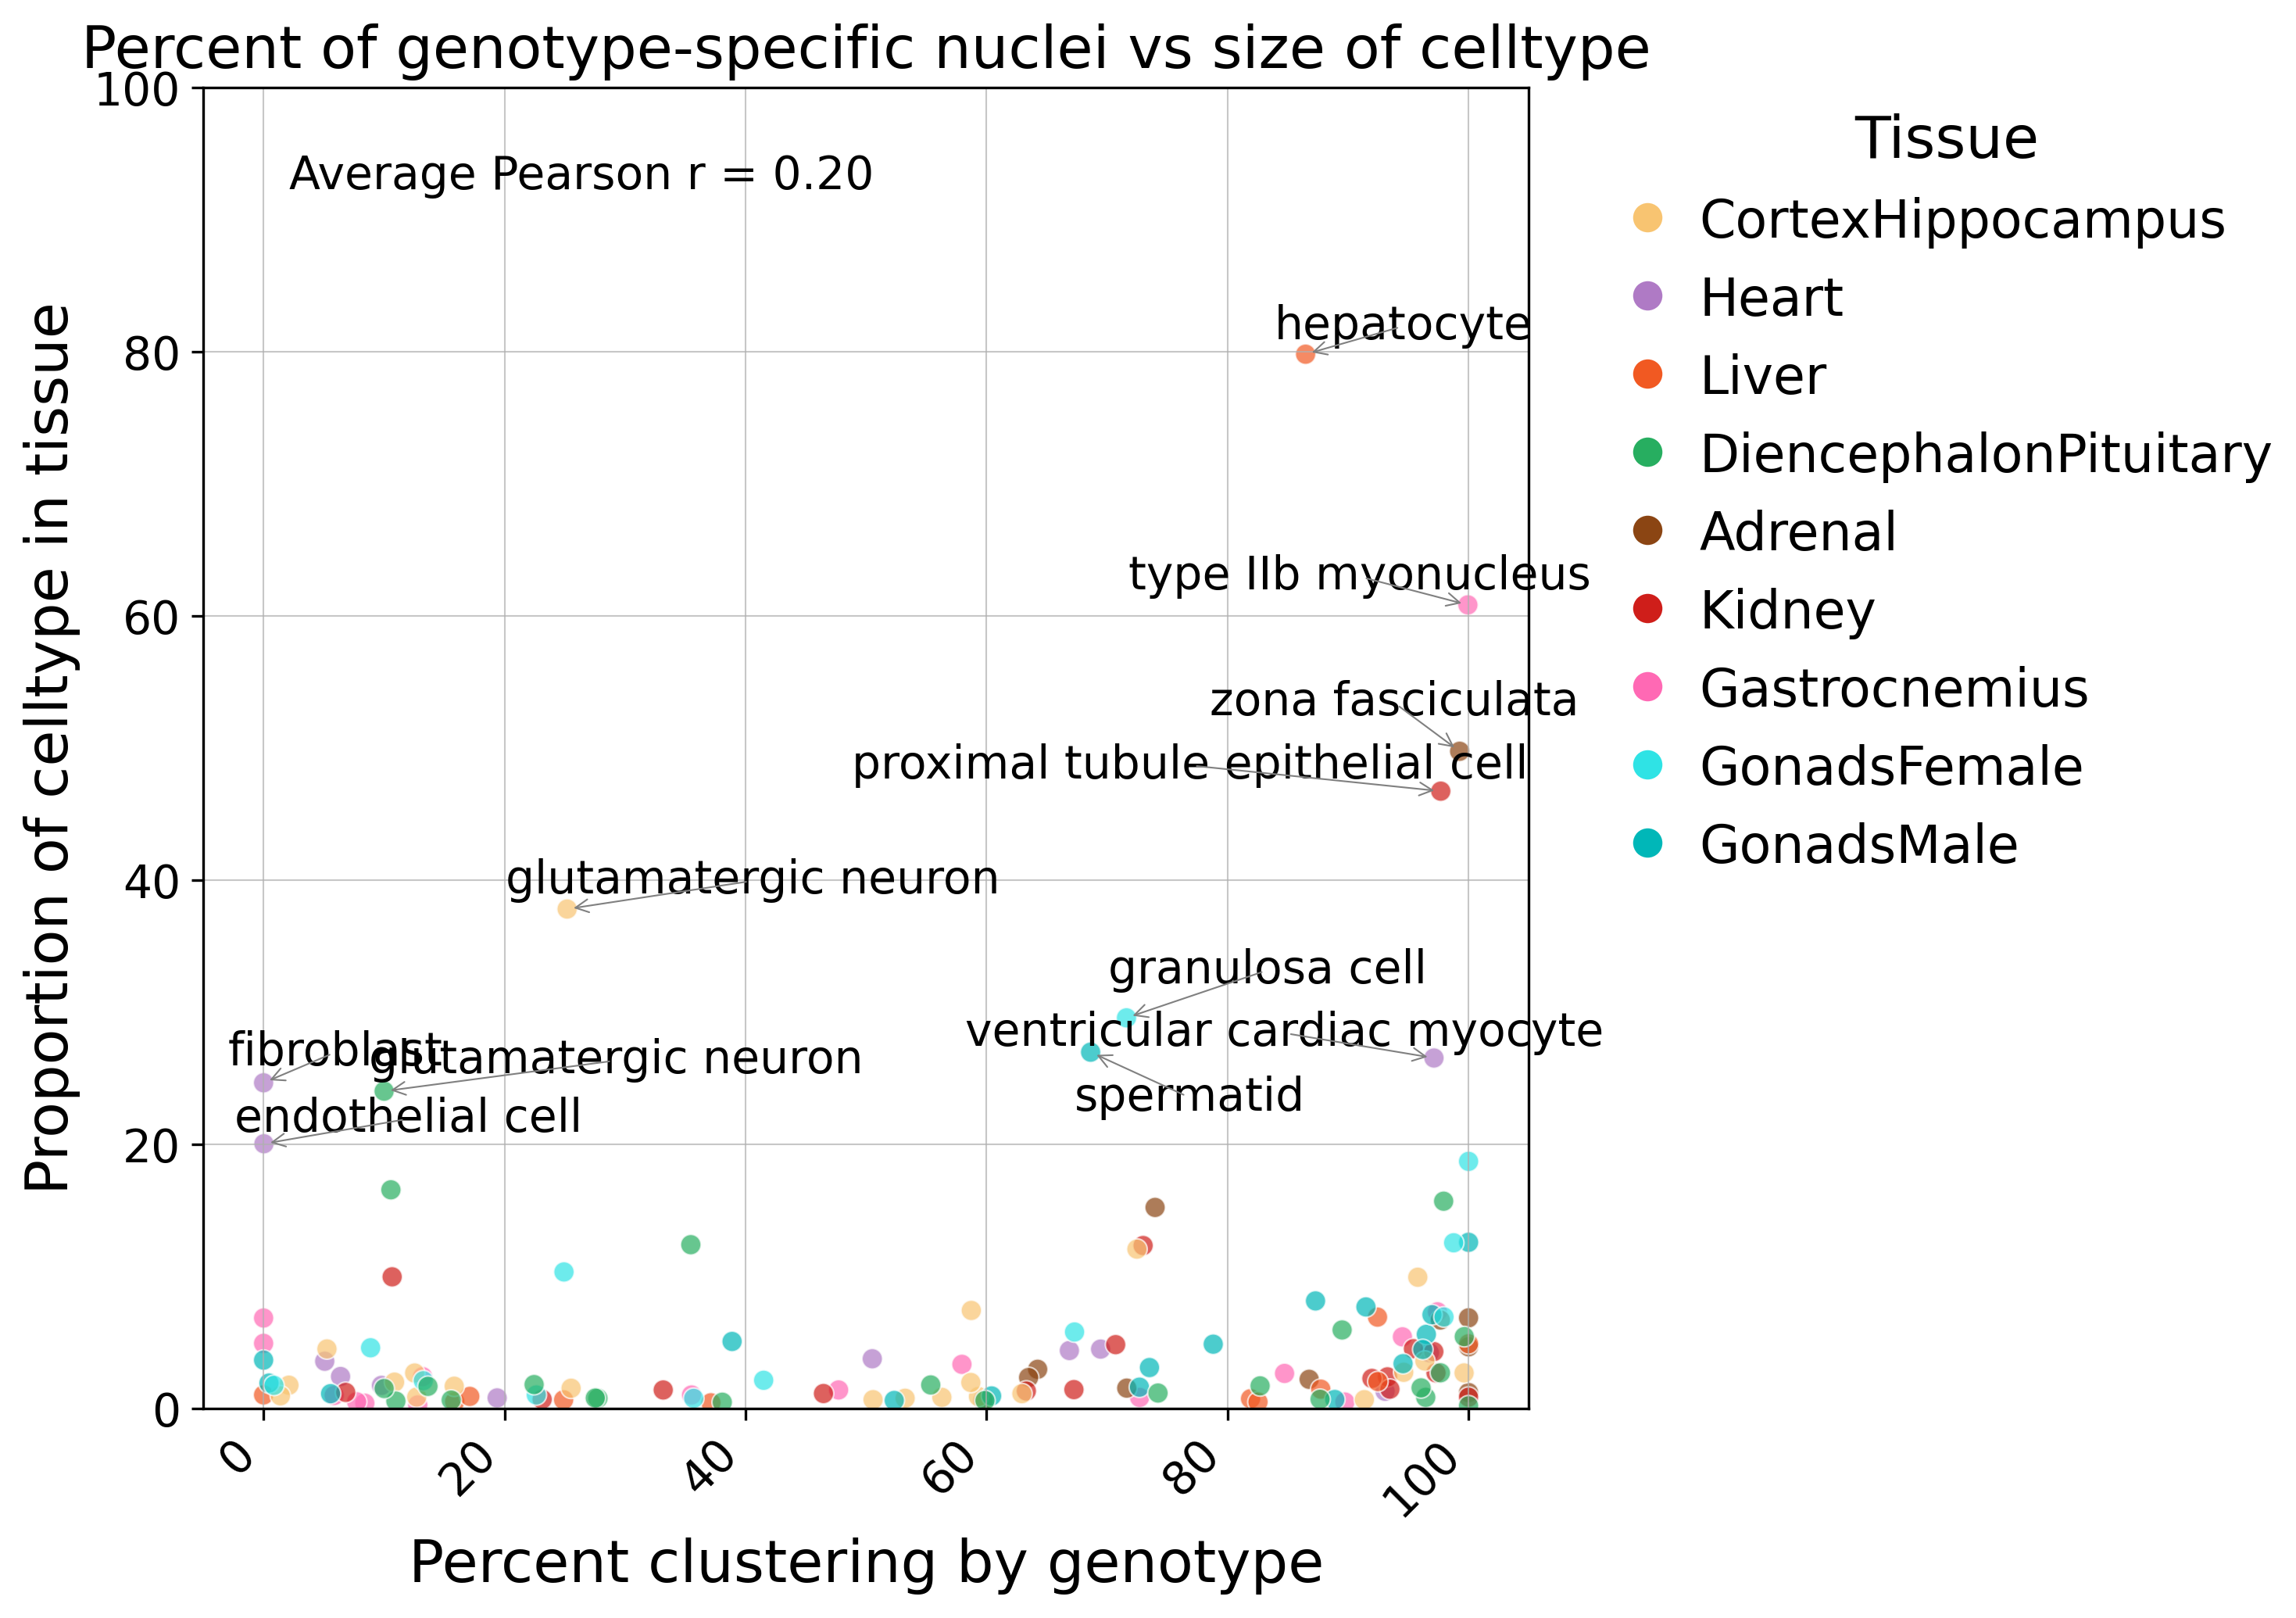

In [8]:
plt.figure(figsize=(10, 7), dpi=300)  # Increase DPI to 300 for higher resolution

correlations = (
    merged_df.groupby('tissue')
    .apply(lambda x: x['pct'].corr(x['proportion_pct']))
    .reset_index(name='pearson_r')
)
average_r = correlations['pearson_r'].mean()

print(f"Average Pearson r: {average_r}")


# Scatterplot with consistent point size based on scaled_size
sns.scatterplot(
    data=merged_df,
    x='pct',
    y='proportion_pct',
    hue='tissue',
    palette=tissue_dict,
    alpha=0.7,
    s=40
)

     
#plt.xlim(0, 20000)  # Start x-axis at 0, no upper limit specified
plt.ylim(0, 100)  # Start y-axis at 0, no upper limit specified


texts = []
for _, row in merged_df.iterrows():
    if row['proportion_pct'] > 20:
        texts.append(
            plt.text(
                row['pct'],
                row['proportion_pct'],
                row['subtype'],  # Label with the cell type or another identifier
                fontsize=14
            )
        )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.5),  # Optional: add arrows for clarity
    only_move={'points': 'xy', 'texts': 'xy'},  # Limit movement to within the plot
    force_text=0.5,  # Strength of text repulsion
    force_points=0.5,  # Strength of point repulsion
)


legend_handles = [
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=tissue)
    for tissue, color in tissue_dict.items()
]


plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title="Tissue",
    title_fontsize=18,
    fontsize=16
)



plt.grid(visible=True, which='both', linewidth=0.5, alpha=0.7)


plt.title("Percent of genotype-specific nuclei vs size of celltype", fontsize = 18)
plt.xlabel("Percent clustering by genotype", fontsize = 18)
plt.ylabel("Proportion of celltype in tissue", fontsize = 18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45, ha='right')

# Add text with average r
plt.text(
    0.02 * plt.xlim()[1],
    0.95 * plt.ylim()[1],
    f"Average Pearson r = {average_r:.2f}",
    fontsize=14,
    ha='left',
    va='top'
)


plt.tight_layout()

plt.savefig("../supp_fig5/clustering_vs_size.png", dpi=300, bbox_inches="tight")
plt.show() 
plt.close()

# Fig. S5b-j

In [9]:
tissues = ['Heart','Liver','Adrenal','Gastrocnemius','Kidney','CortexHippocampus','DiencephalonPituitary','GonadsMale','GonadsFemale']
all_geno_chisq_df = []
for tissue in tissues:
    geno_chisq_df = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/figures/subclustering_subtypes_final/{tissue}_genotype_chisq_n_cells_per_genotype_40_n_cells_filter.csv')
    all_geno_chisq_df.append(geno_chisq_df)
all_geno_chisq_df = pd.concat(all_geno_chisq_df, ignore_index=True)


In [10]:
summary = (
    all_geno_chisq_df
    .groupby(['tissue', 'subtype'])
    .agg(
        n_cells=('n_cells', 'sum'),
        total_n_cells=('total_n_cells', 'sum')
    )
    .reset_index()
)

summary['pct'] = (summary['n_cells'] / summary['total_n_cells']) * 100
summary['subtype_tissue'] = summary['subtype'] + '_' + summary['tissue']

subset = summary[summary['pct'] >= 0]
subset = subset['subtype_tissue'].tolist()


In [11]:
heatmap_df = (
    all_geno_chisq_df
    .groupby(['tissue', 'Genotype', 'subtype'])
    .agg(
        n_cells=('n_cells', 'sum'),
        total_n_cells=('total_n_cells', 'sum')
    )
    .reset_index()
)

heatmap_df['pct'] = (heatmap_df['n_cells'] / heatmap_df['total_n_cells']) * 100
heatmap_df['subtype_tissue'] = heatmap_df['subtype'] + '_' + heatmap_df['tissue']
heatmap_df = heatmap_df[heatmap_df['subtype_tissue'].isin(subset)]


In [12]:
df_row = heatmap_df[['subtype_tissue', 'subtype', 'tissue']]
df_row = df_row.drop_duplicates()
df_row = df_row.set_index("subtype_tissue", drop=False)


In [13]:
plot_df = heatmap_df.pivot_table(index='subtype_tissue', columns='Genotype', values='pct')
plot_df = plot_df.fillna(0)


In [14]:
df_col = pd.DataFrame({
    "Genotype": plot_df.columns,
    "Strain type": ["Wild" if x in ["CASTJ","PWKJ","WSBJ"] else "Lab" for x in plot_df.columns]
})
df_col = df_col.drop_duplicates()

genotype_categories = ['AJ','B6J','129S1J','NODJ','NZOJ','CASTJ','PWKJ','WSBJ']
df_col['Genotype'] = pd.Categorical(df_col['Genotype'], categories=genotype_categories, ordered=True)
df_col.sort_values(['Genotype'], inplace=True)
df_col = df_col.set_index("Genotype", drop=False)

col_ha = pch.HeatmapAnnotation(Genotype=pch.anno_simple(df_col['Genotype'],colors=geno_dict),
                               Type=pch.anno_simple(df_col['Strain type'],colors=strain_dict),
                               verbose=1,
                               label_kws = {'visible': False},
                               axis=1)

left_ha = pch.HeatmapAnnotation(Tissue=pch.anno_simple(df_row['tissue'],colors=tissue_dict),vmin=0,
                                label_kws = {'visible': False},
                                plot_kws={'vmax': 100},
                                axis=0)


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


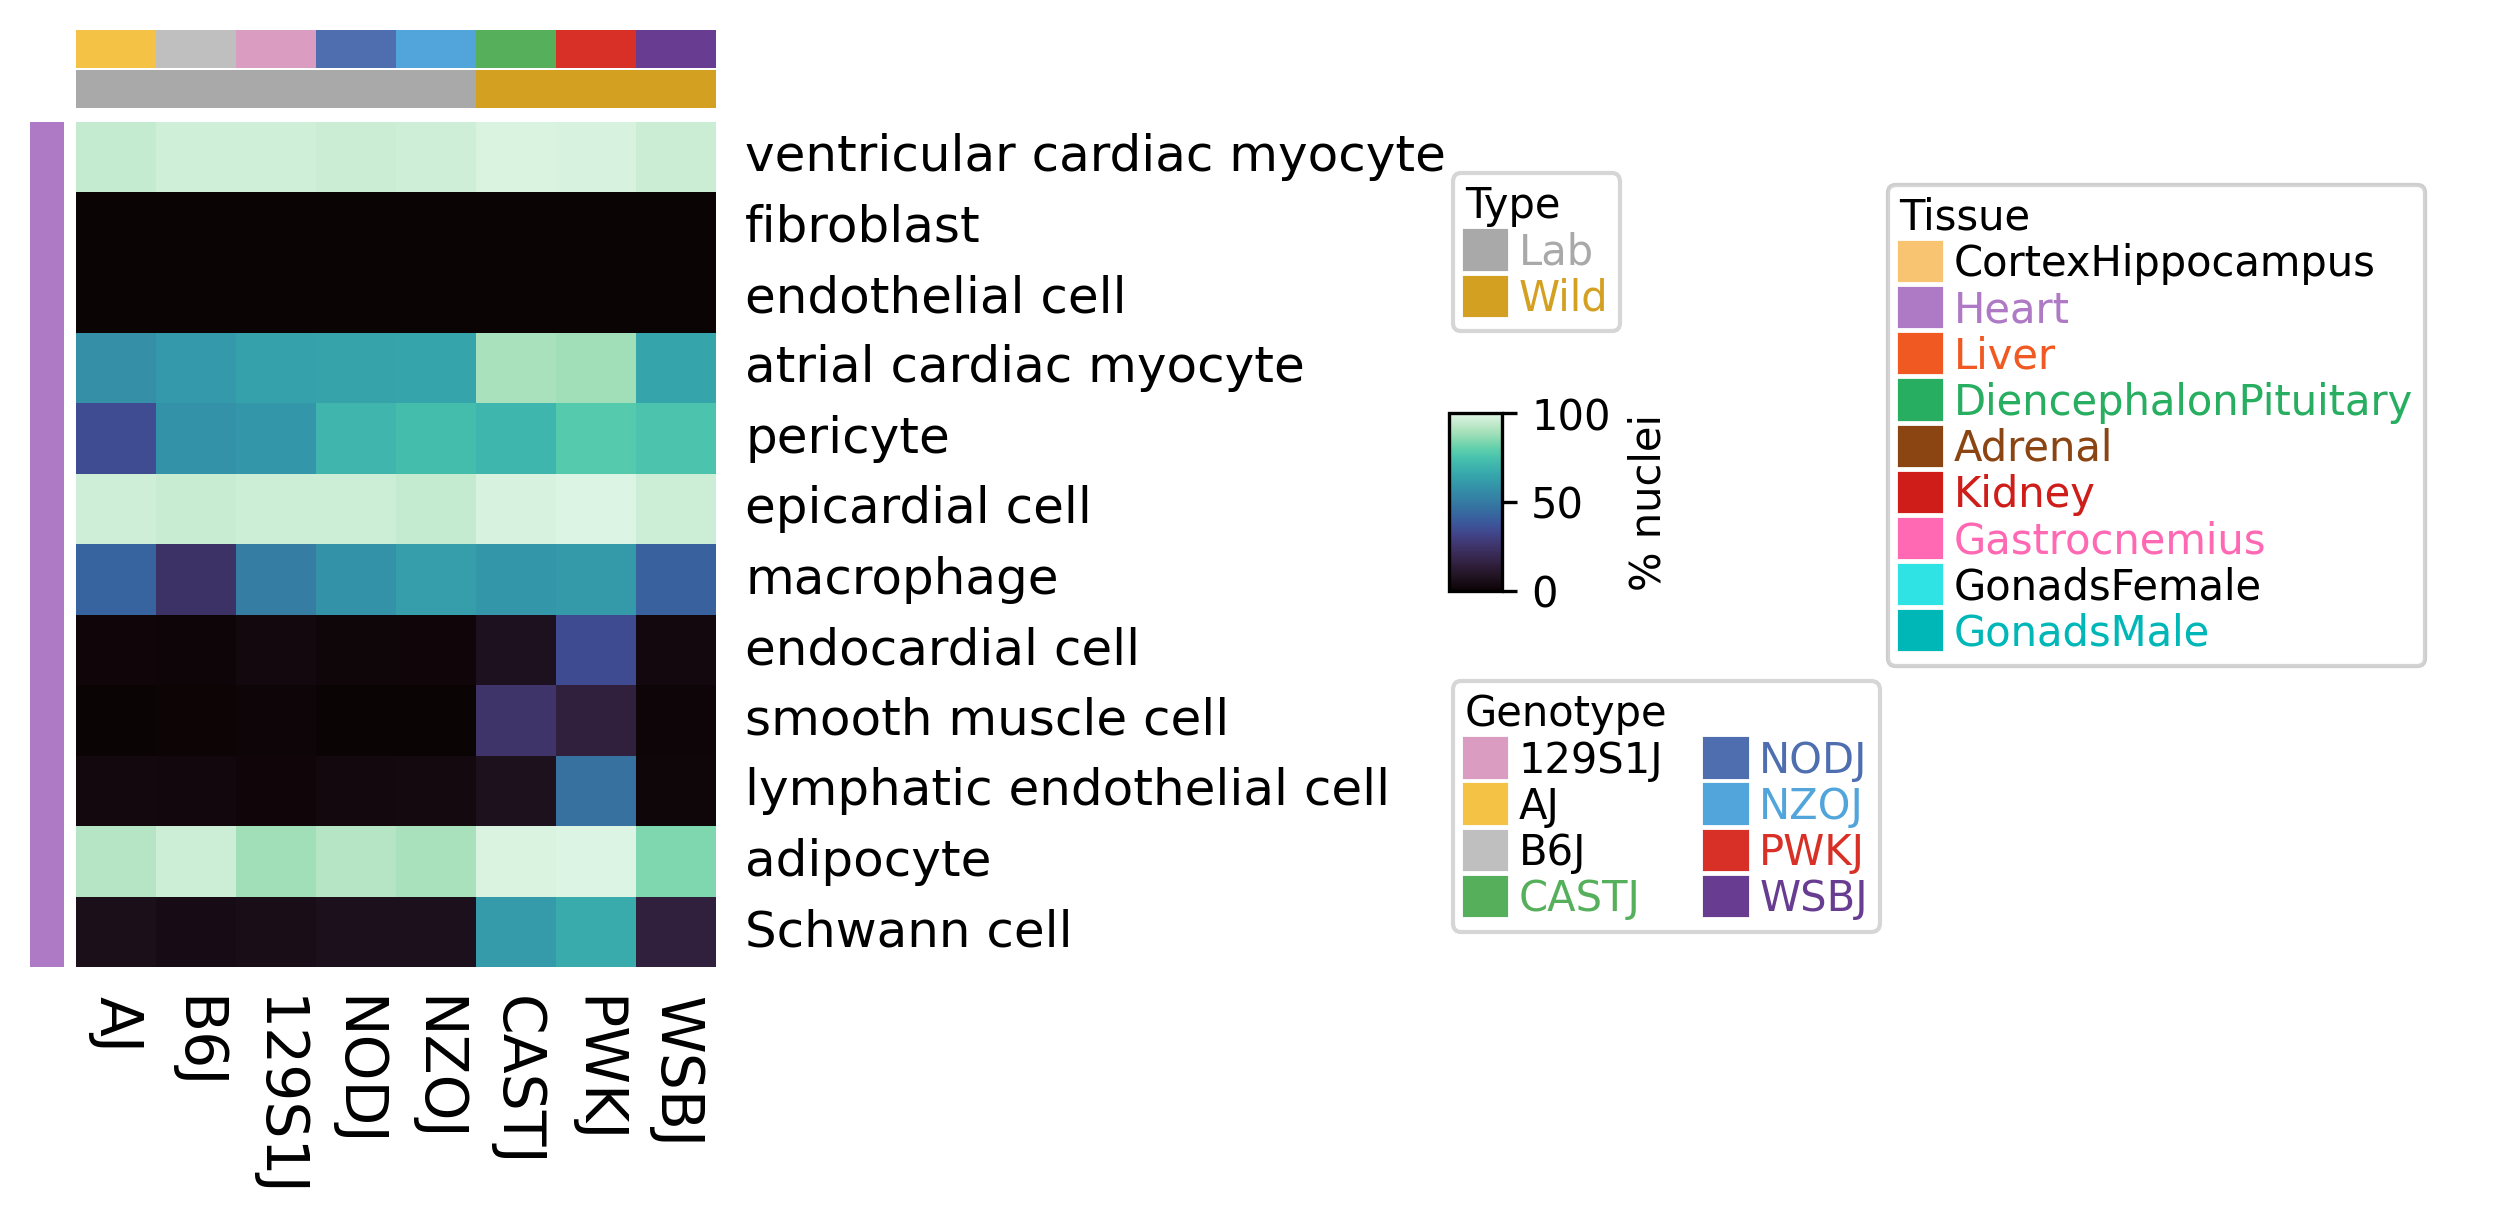

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


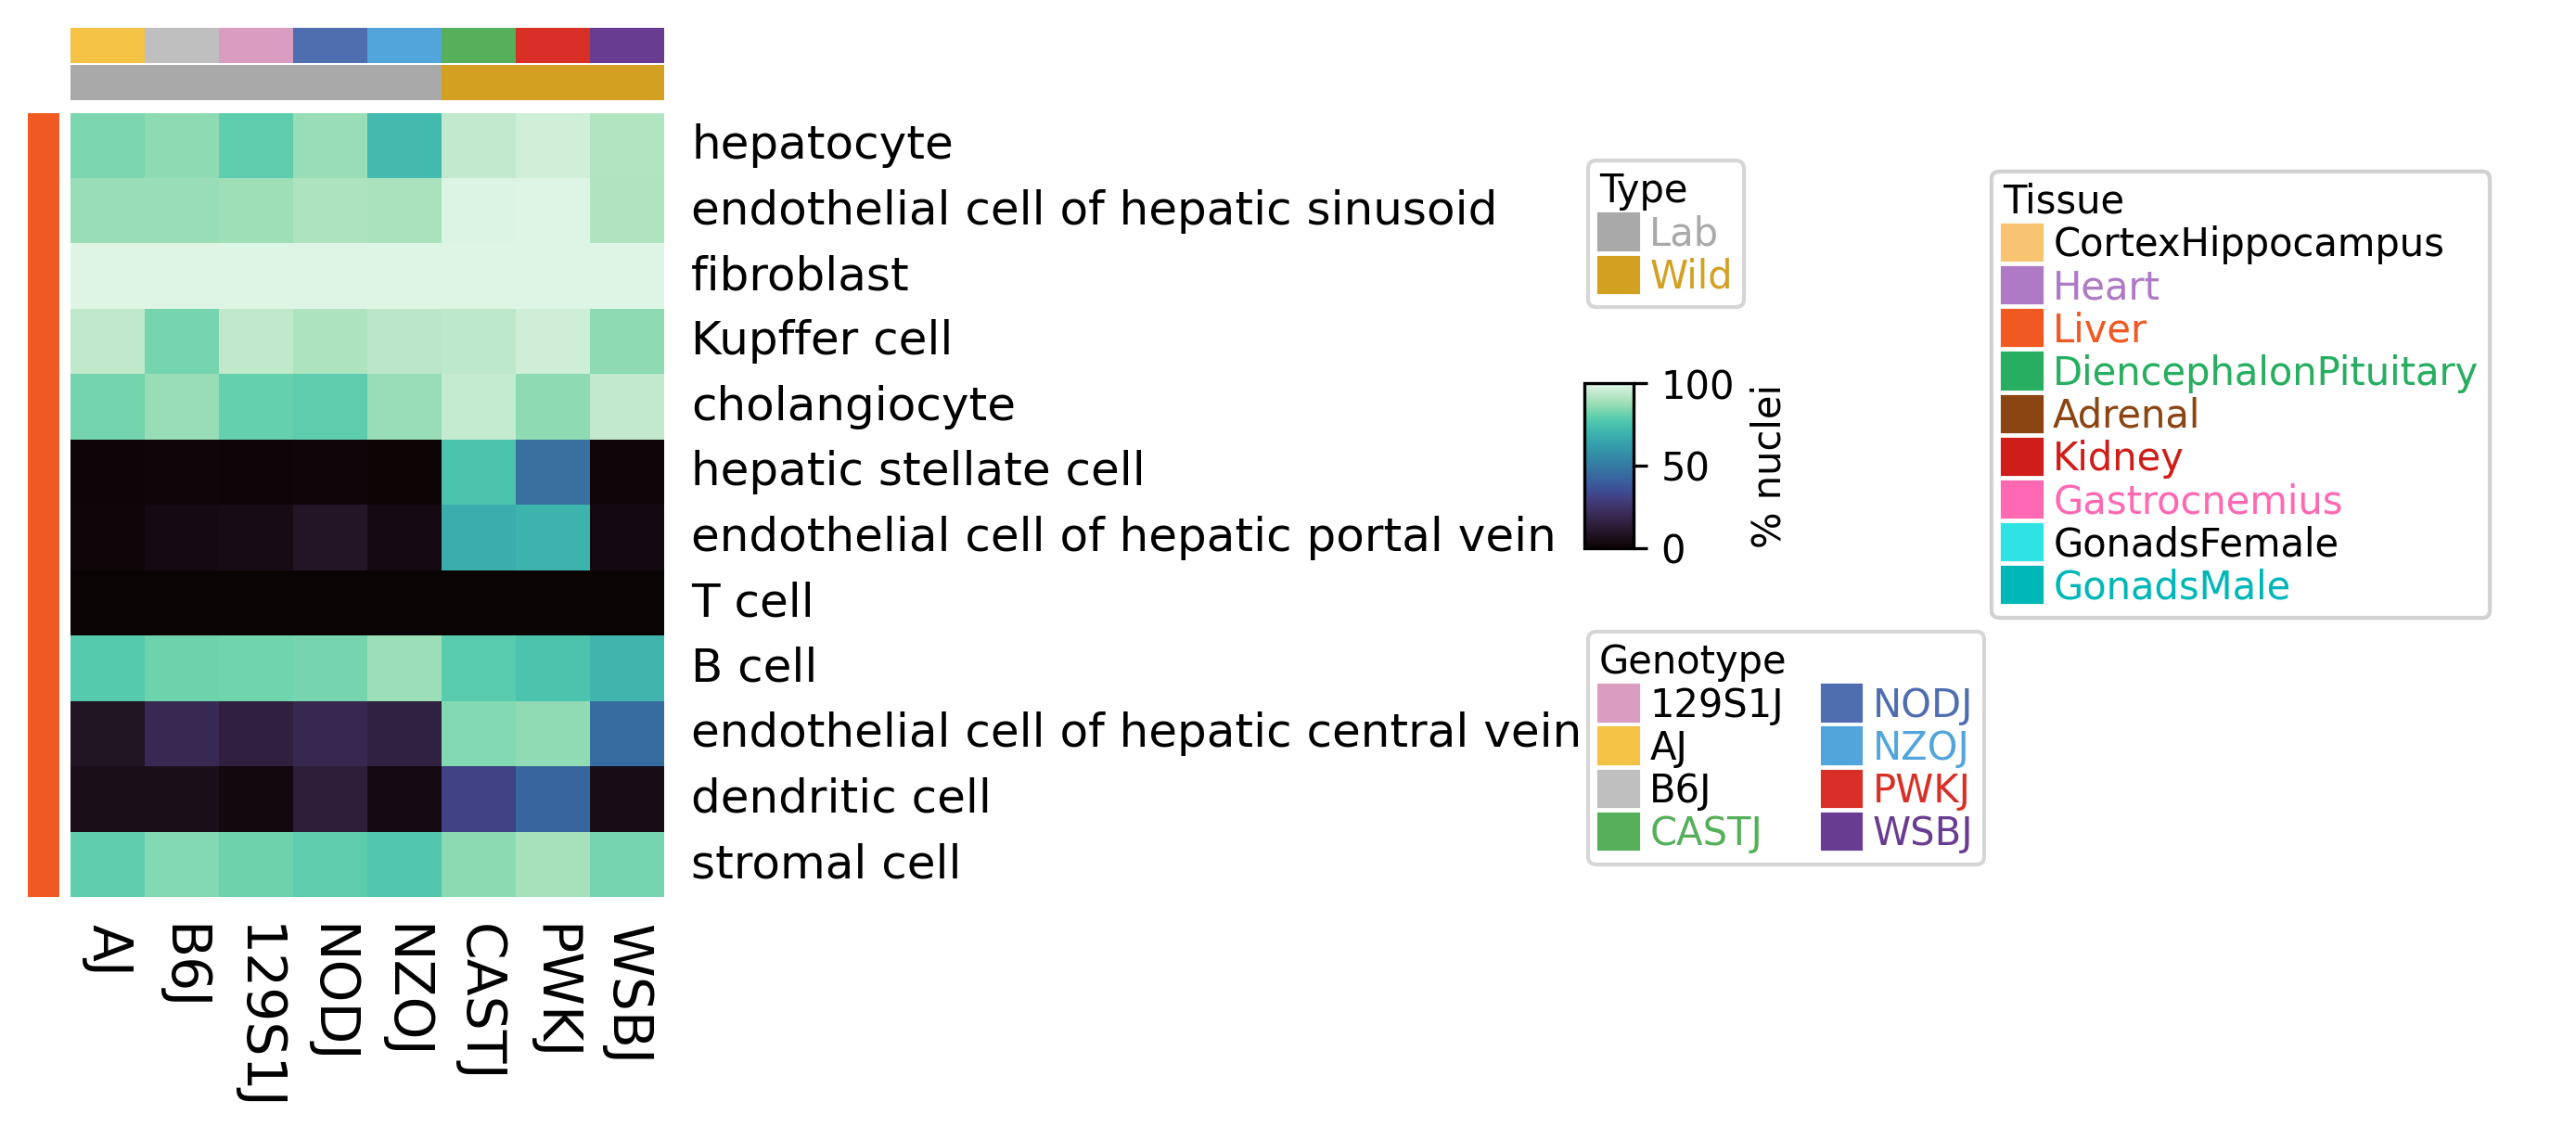

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


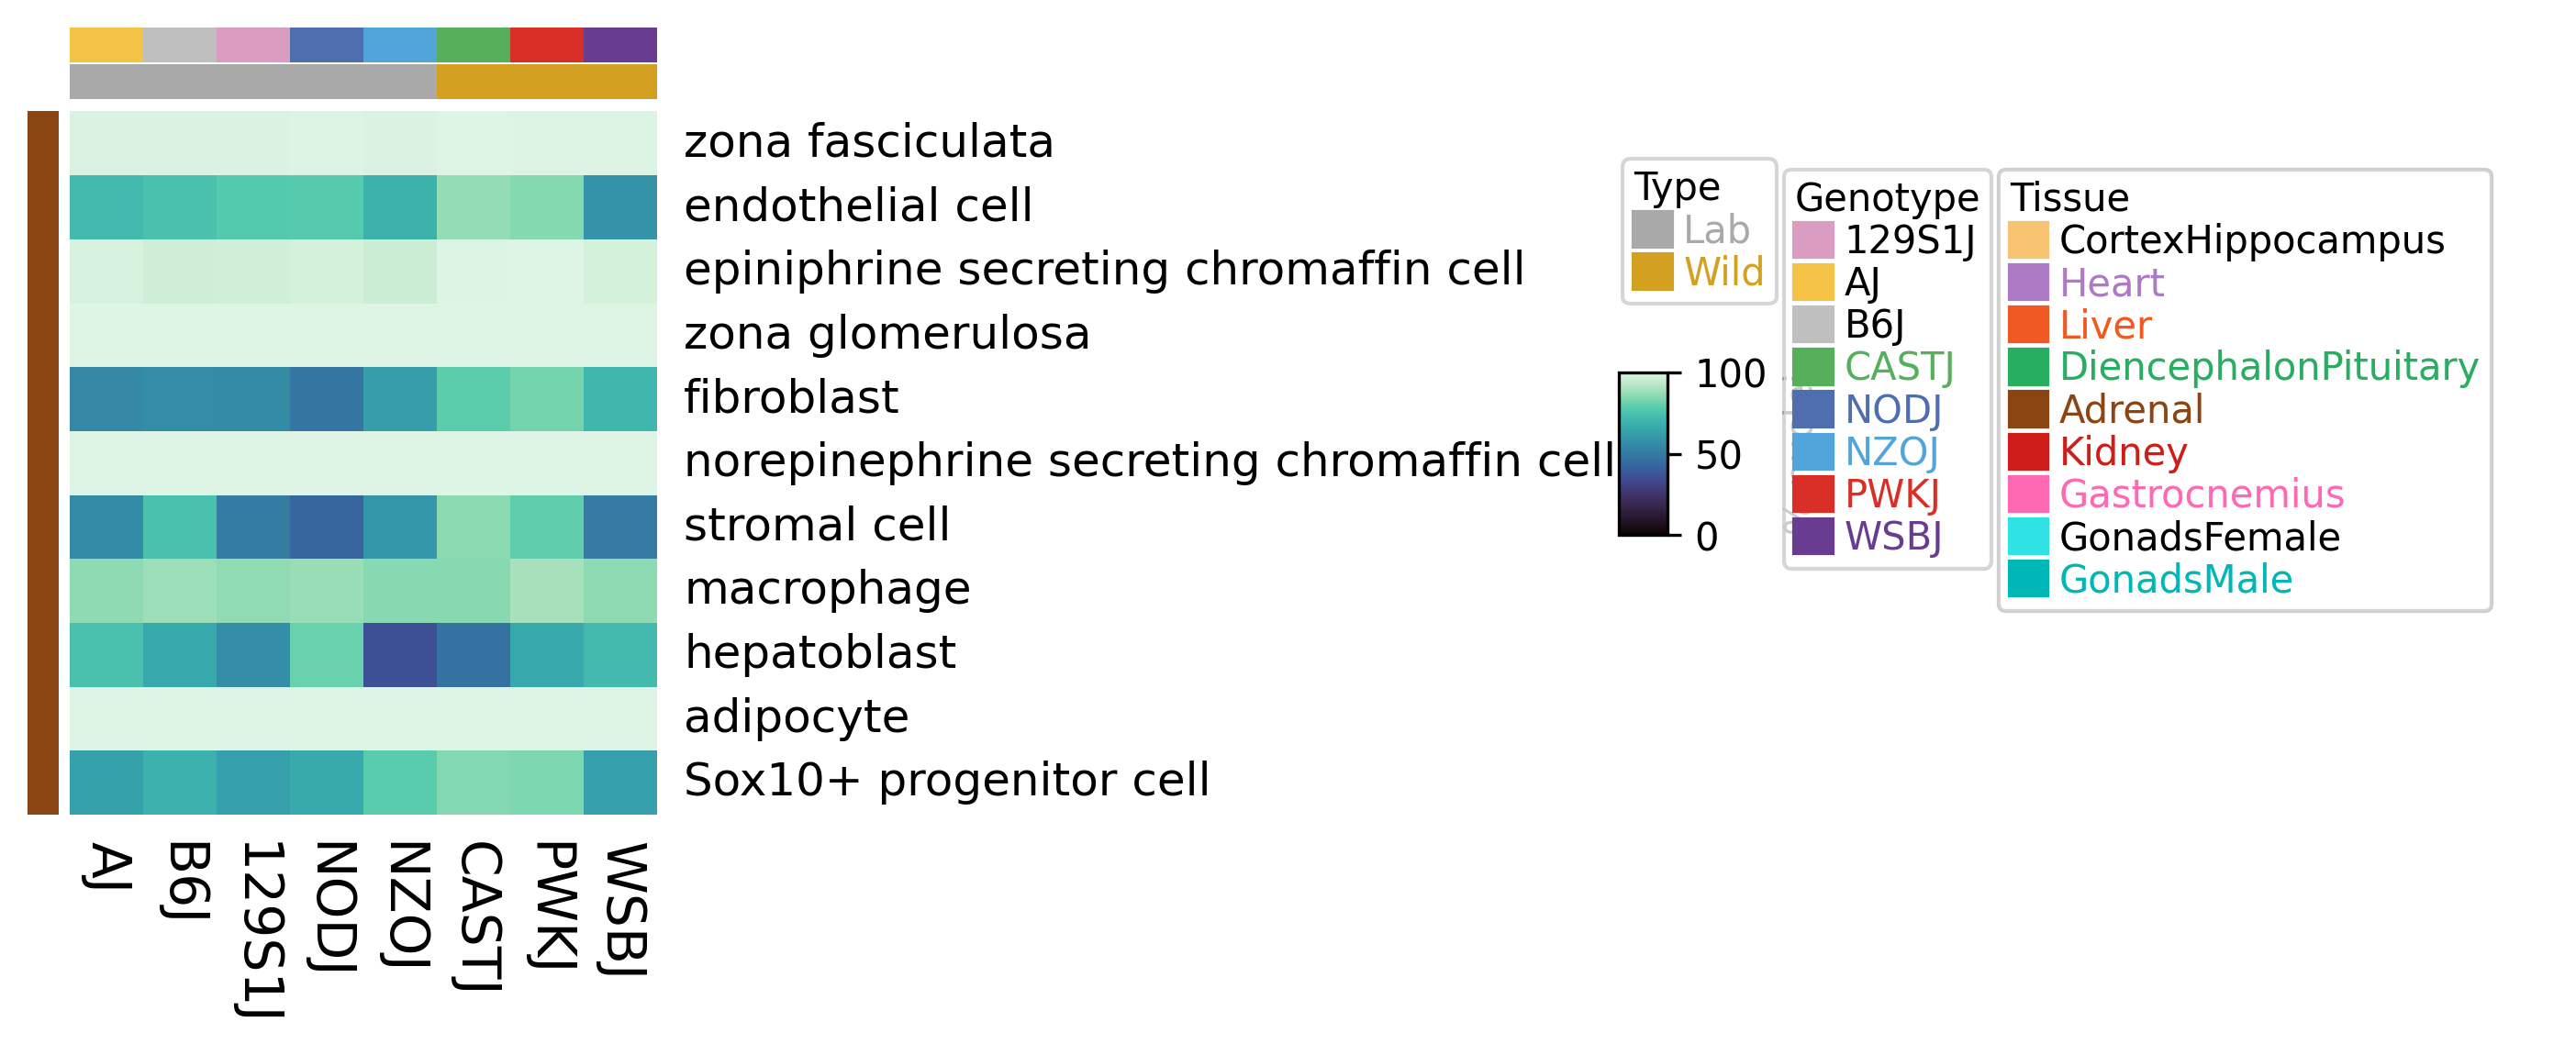

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


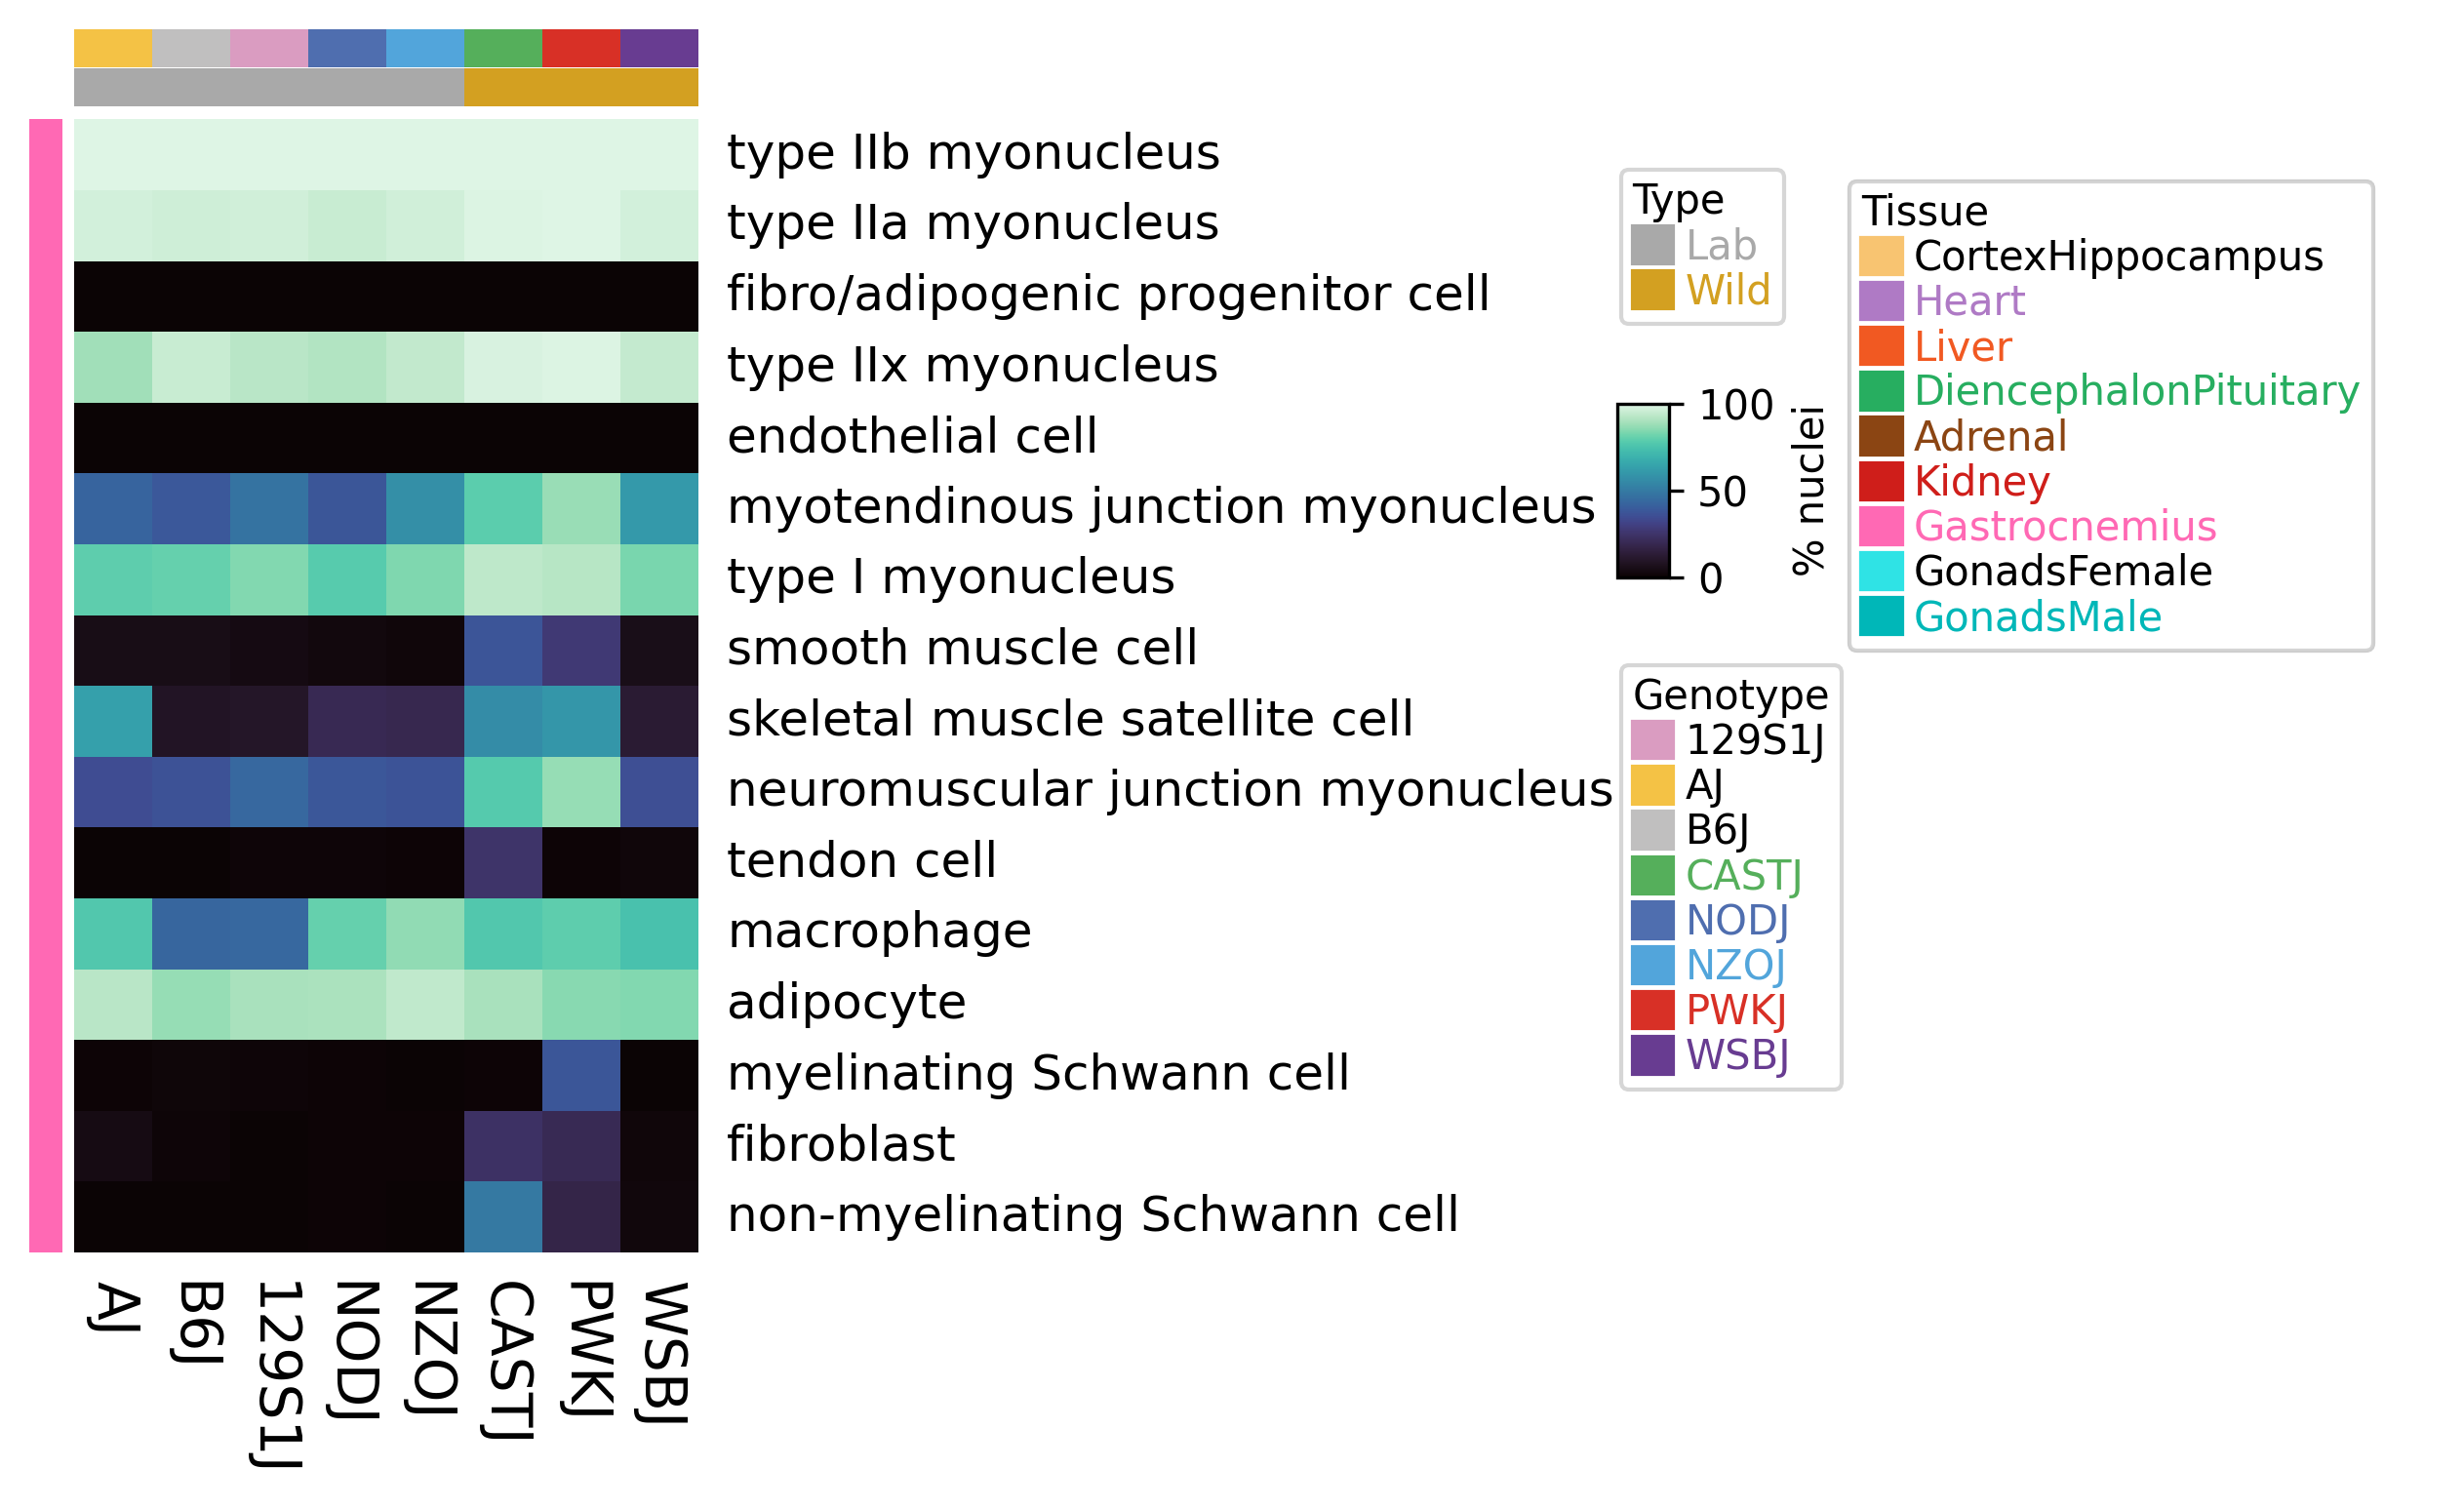

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


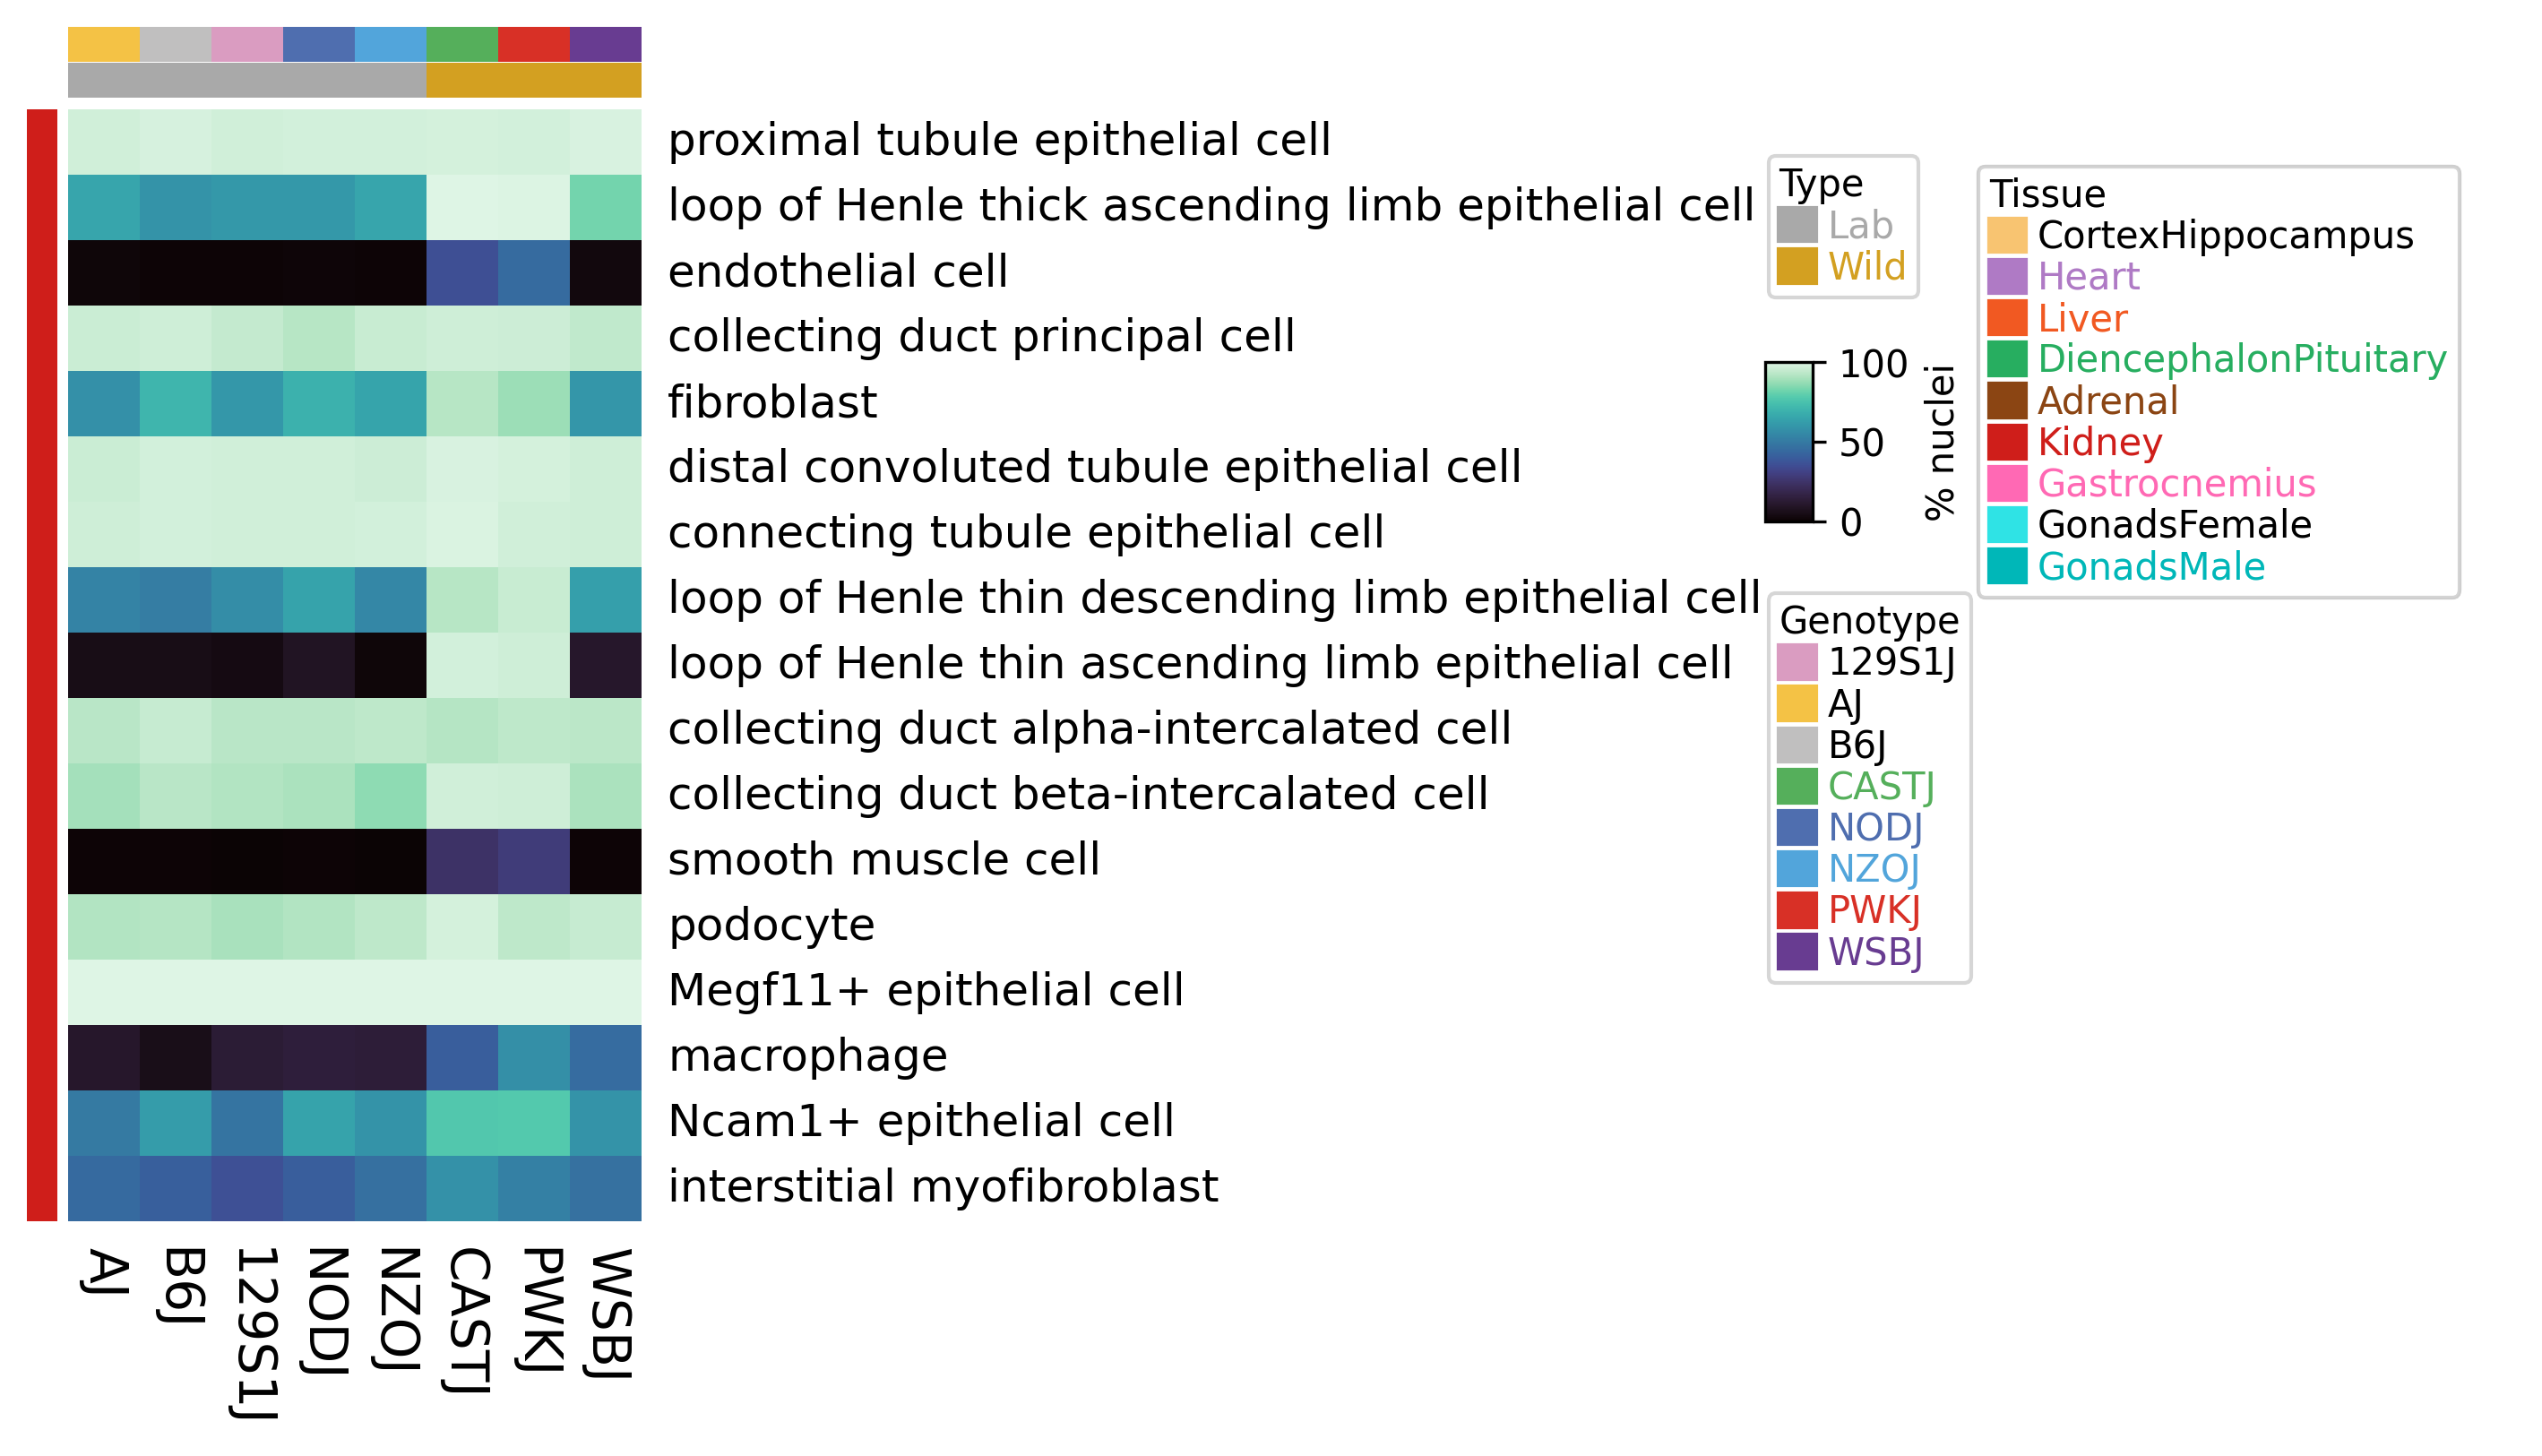

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm


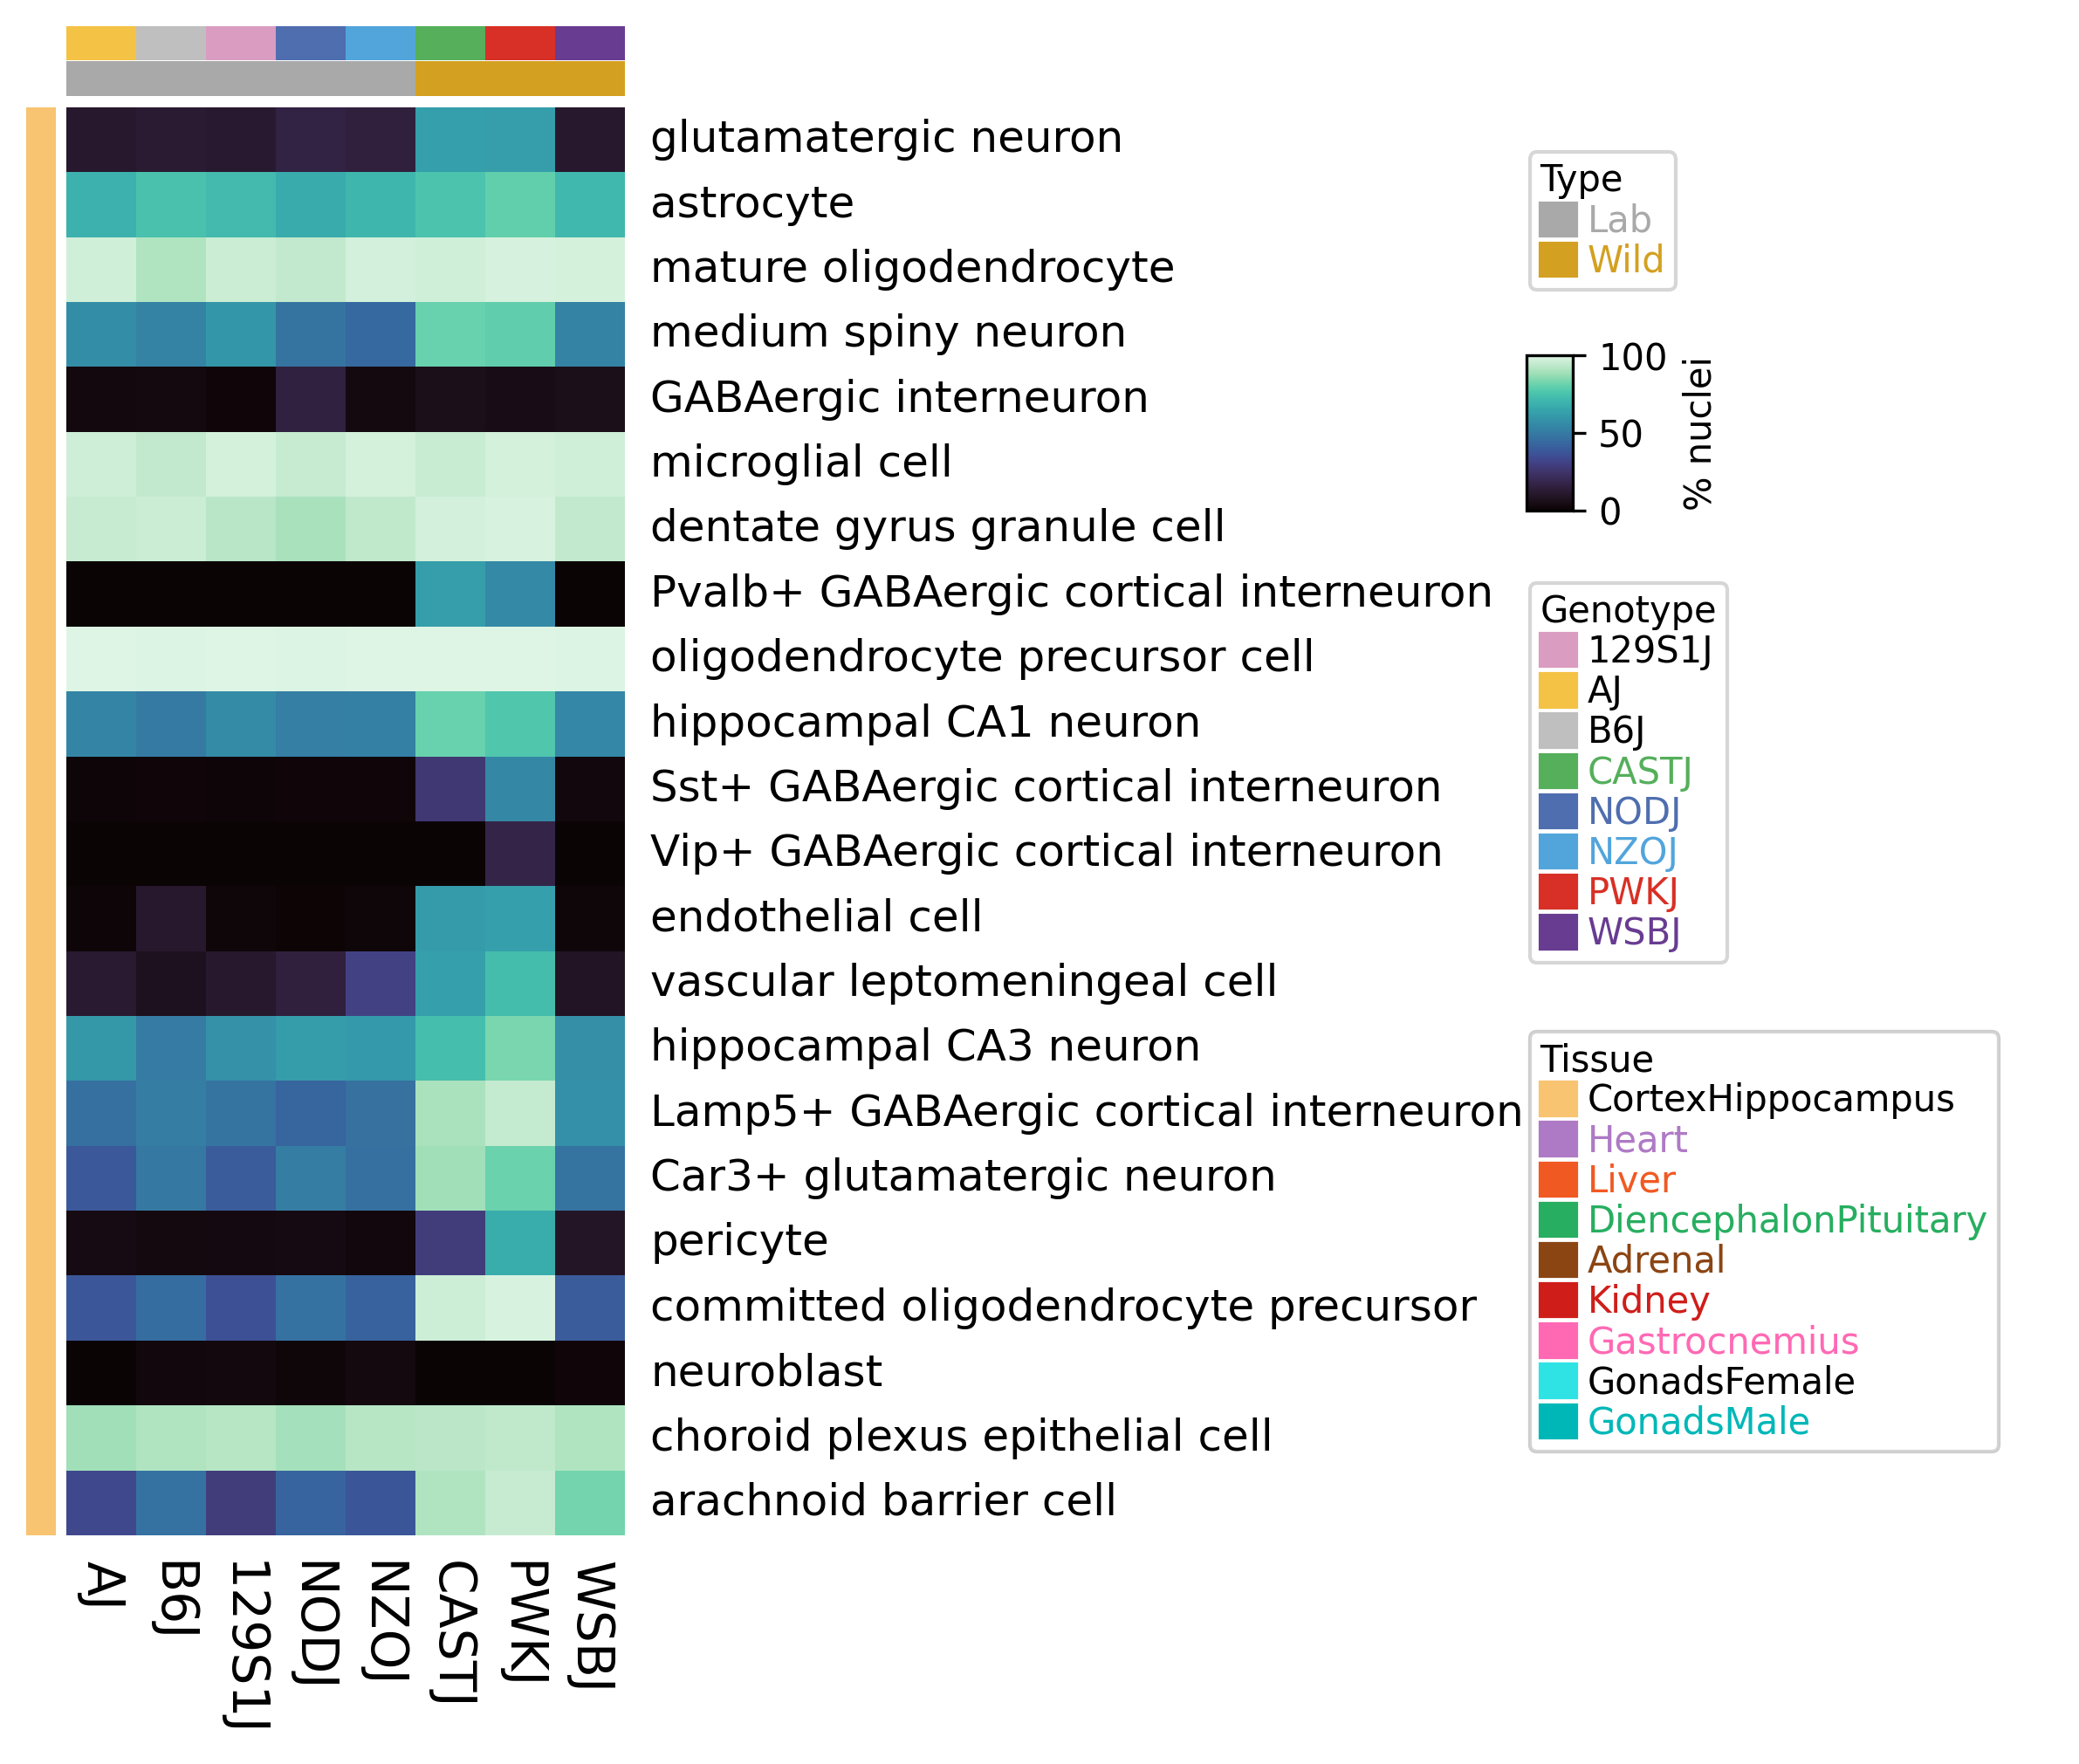

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm


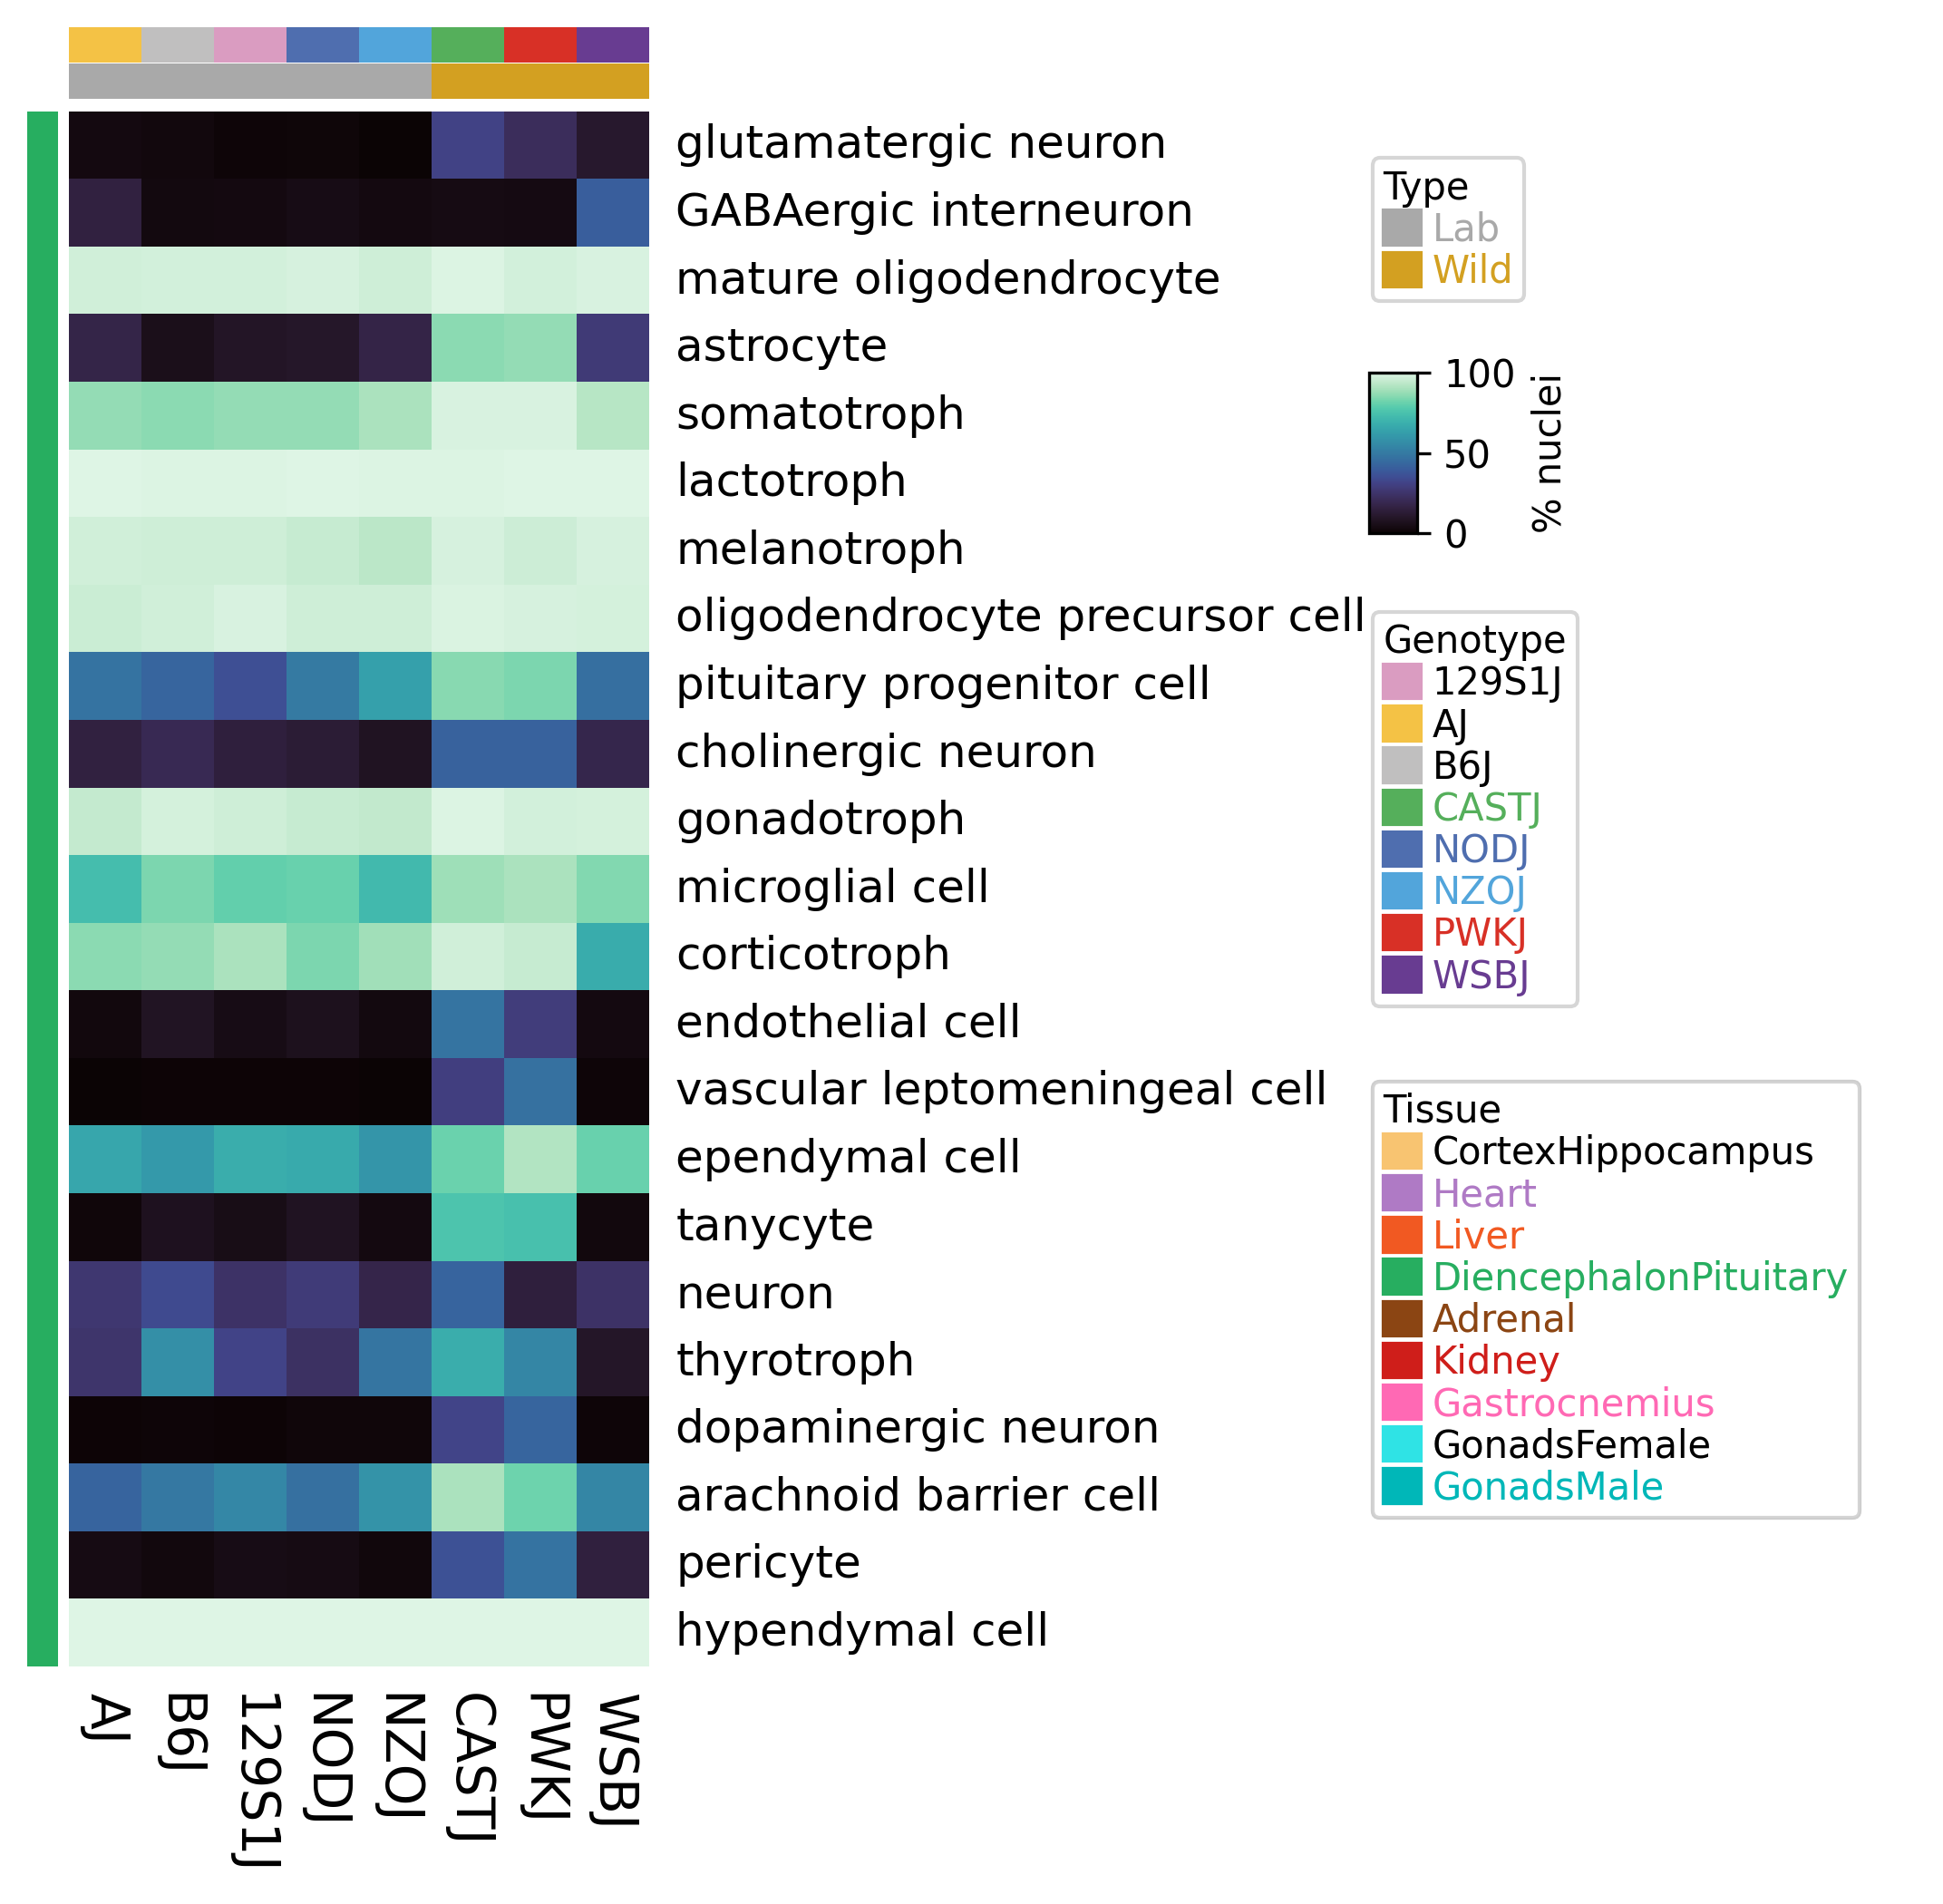

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol


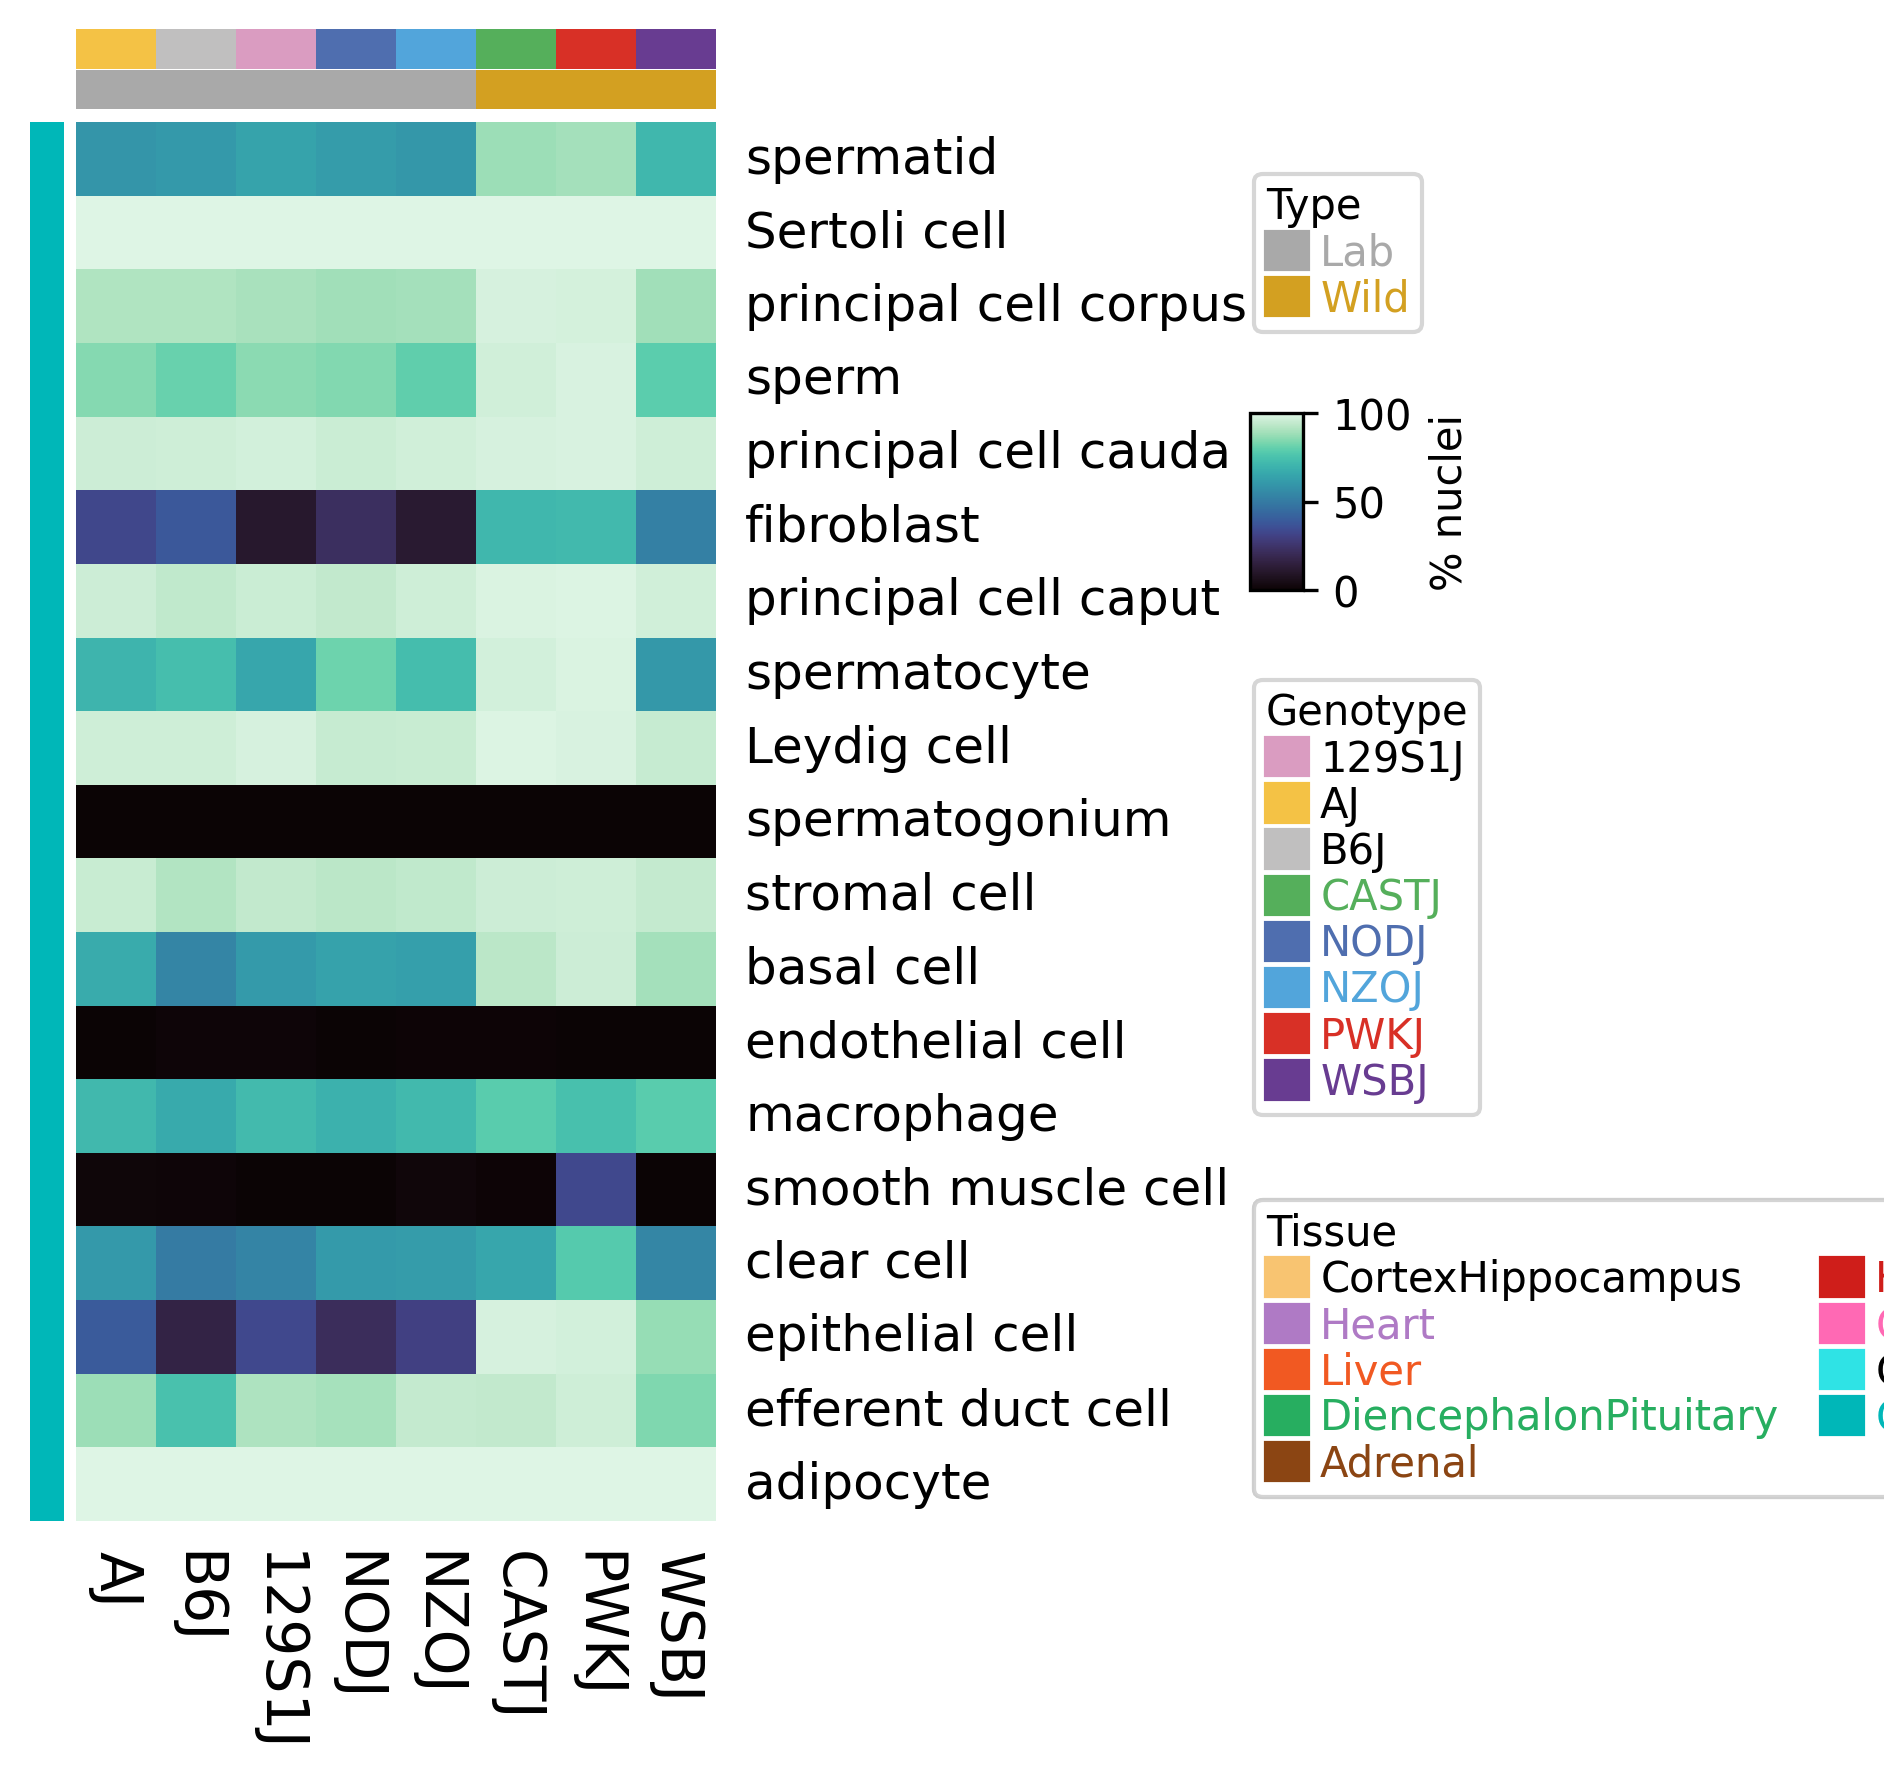

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


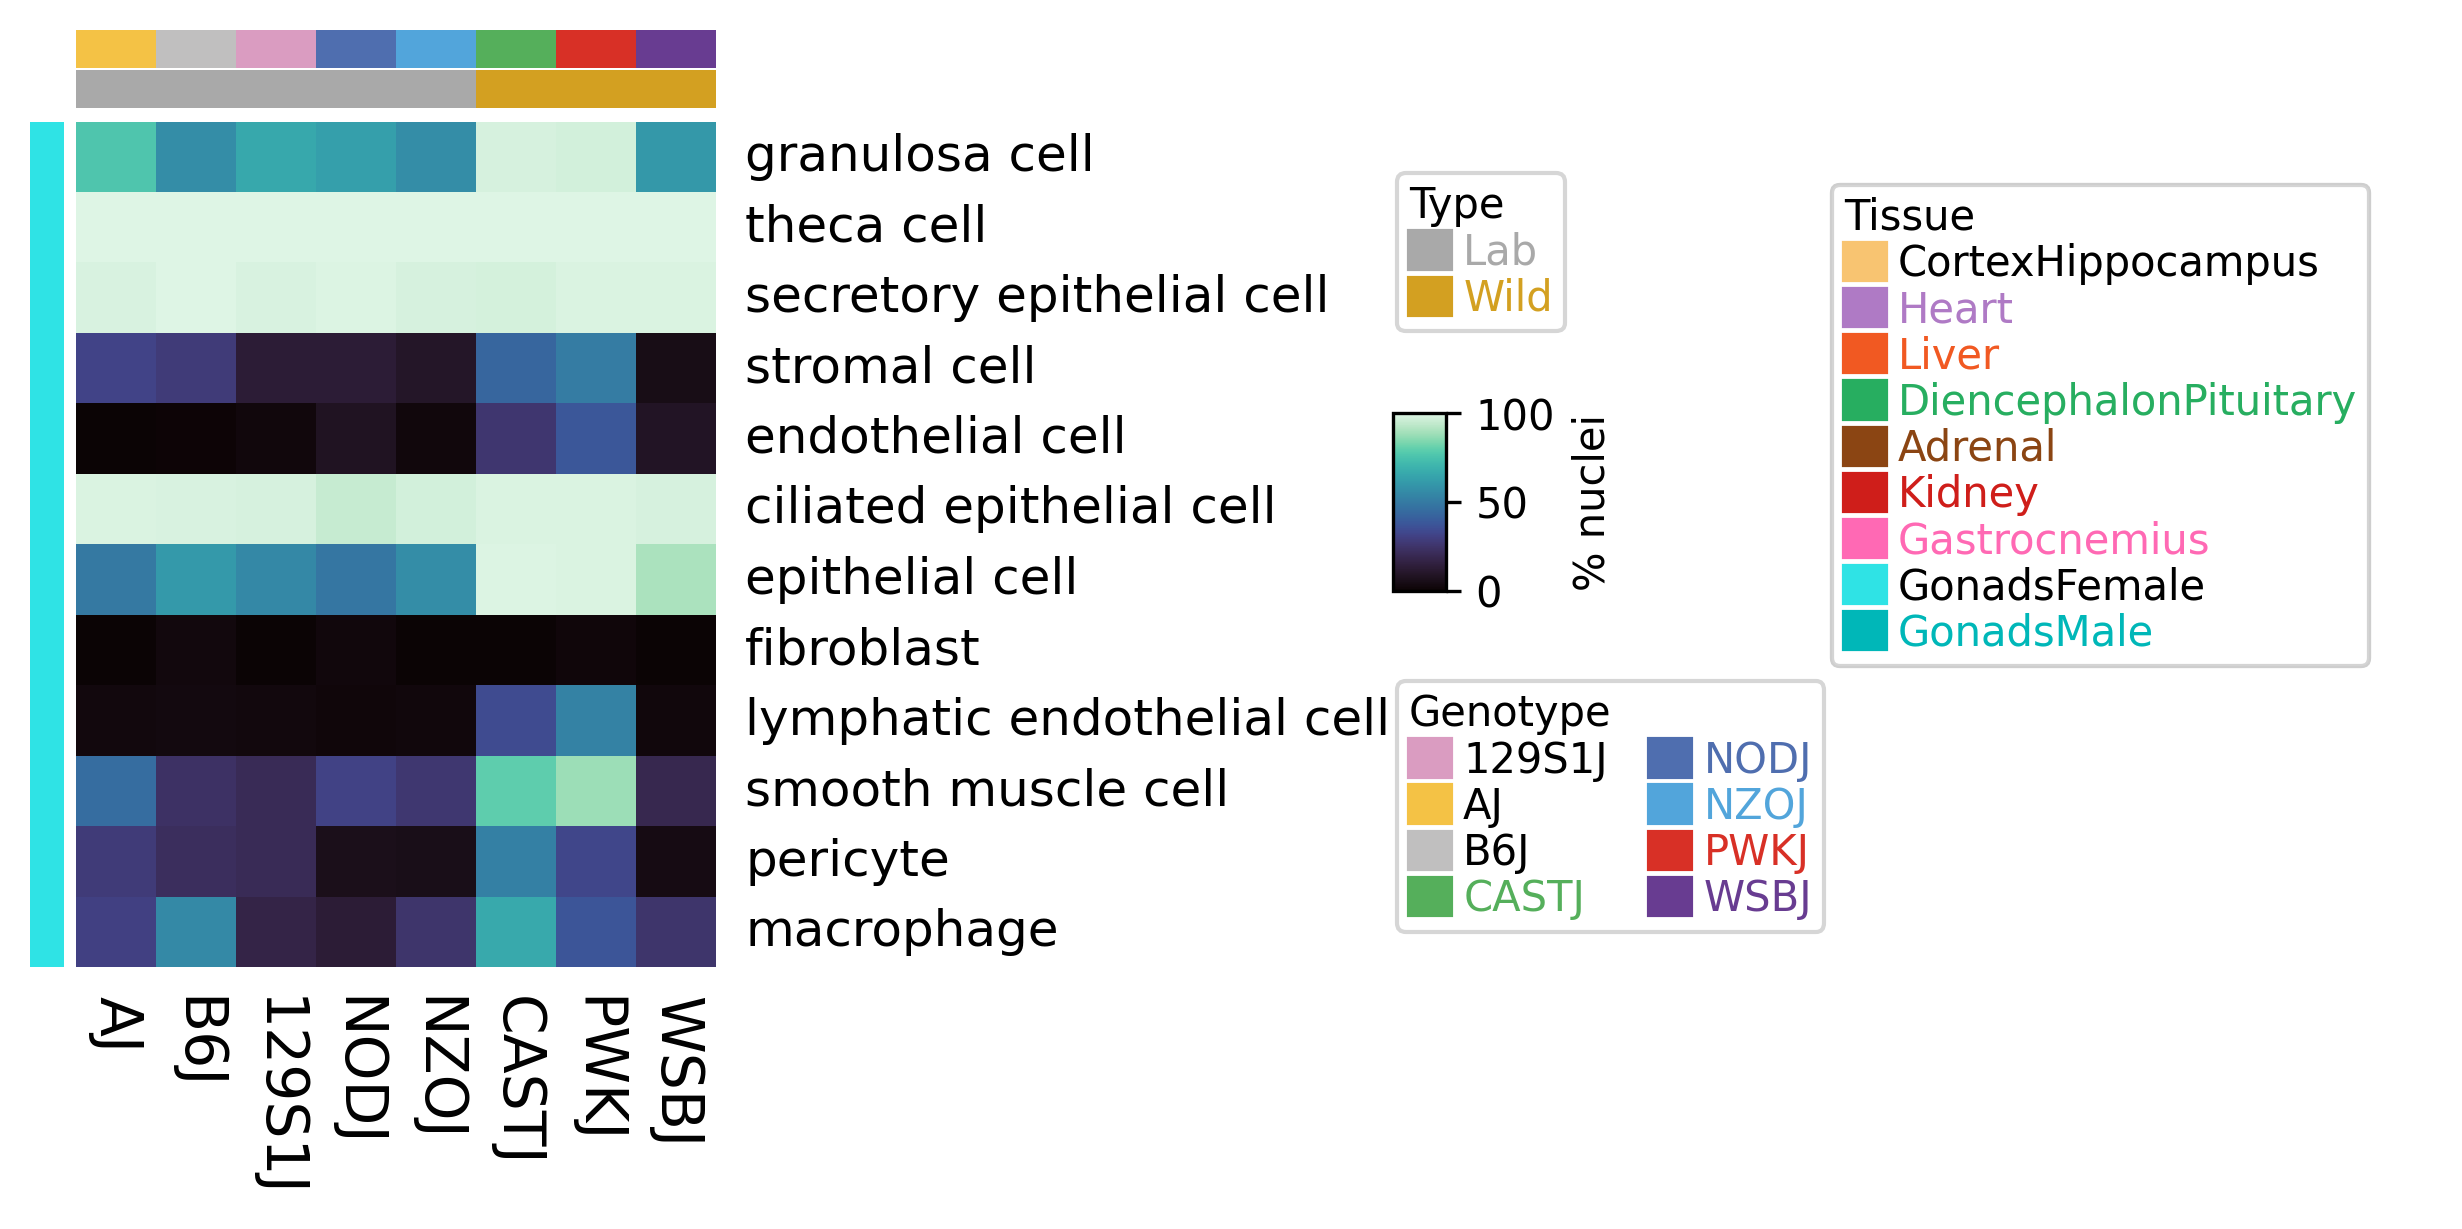

In [15]:
for tissue in tissues:
    heatmap_df_tissue = heatmap_df[heatmap_df['tissue'] == tissue].copy()

    # Create df_row with unique subtypes and total_n_cells for sorting
    df_row = (
        heatmap_df_tissue[['subtype', 'total_n_cells']]
        .drop_duplicates(subset=['subtype'])  # 1 row per subtype
        .sort_values('total_n_cells', ascending=False)  # biggest first
        .set_index('subtype', drop=False)
    )

    # Make sure Tissue annotation stays aligned
    df_row['tissue'] = tissue

    left_ha = pch.HeatmapAnnotation(
        Tissue=pch.anno_simple(df_row['tissue'], colors=tissue_dict),
        vmin=0,
        label_kws={'visible': False},
        plot_kws={'vmax': 100},
        axis=0
    )

    plot_df = heatmap_df_tissue.pivot_table(index='subtype', columns='Genotype', values='pct').fillna(0)

    # Use sorted subtype order!
    plot_df = plot_df.loc[df_row.index.tolist(), df_col.index.tolist()]

    n_rows = plot_df.shape[0]
    height_per_row = 0.3
    base_height = 1.0
    fig_height = max(base_height, n_rows * height_per_row)

    plt.figure(figsize=(3, fig_height), dpi=300)

    cm = pch.ClusterMapPlotter(
        data=plot_df,
        show_rownames=True,
        show_colnames=True,
        cmap="mako",
        label="% nuclei",
        top_annotation=col_ha,
        left_annotation=left_ha,
        row_cluster=False,
        col_cluster=False,
        vmin=0,
        vmax=100,
        yticklabels_kws={'labelsize': 12},
        xticklabels_kws={'labelsize': 14}
    )

    plt.savefig(f"../supp_fig5/{tissue}_heatmap.png", bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()


# Fig. S5k

In [16]:
tissues = ['Heart','Liver','Adrenal','Gastrocnemius','Kidney','Liver',
           'CortexHippocampus','DiencephalonPituitary']

all_chisq_df = []
for tissue in tissues:
    chisq_sex_results = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/figures/subclustering_subtypes_final/{tissue}_sex_chisq_n_cells_per_genotype_each_geno_no_rep_filter_40_n_cells_filter.csv')
    all_chisq_df.append(chisq_sex_results)
df = pd.concat(all_chisq_df, ignore_index=True)


annot = pd.read_csv('../fig2/annots.csv') # new general cell type labels
annot = annot[annot['subtype'] != 'low quality']
annot = annot.rename(columns={'Tissue': 'tissue'})
df = df.merge(annot[['subtype','tissue','new_general_celltype']],how='left',on=['subtype', 'tissue'])


In [17]:
heatmap_df = (
    df
    .groupby(['genotype', 'new_general_celltype'])
    .agg(
        n_cells=('n_cells', 'sum'),
        total_n_cells=('total_n_cells', 'sum')
    )
    .reset_index()
)

heatmap_df['pct'] = (heatmap_df['n_cells'] / heatmap_df['total_n_cells']) * 100

plot_df = heatmap_df.pivot_table(index='new_general_celltype', columns='genotype', values='pct')
plot_df = plot_df.fillna(0)

cell_counts = heatmap_df.groupby('new_general_celltype')['total_n_cells'].sum()
ordered_cell_types = cell_counts.sort_values(ascending=False).index

plot_df = plot_df.loc[ordered_cell_types]



In [18]:
df_col = pd.DataFrame({
    "Genotype": plot_df.columns,
    "Strain type": ["Wild" if x in ["CASTJ","PWKJ","WSBJ"] else "Lab" for x in plot_df.columns]
})
df_col = df_col.drop_duplicates()

genotype_categories = ['AJ','B6J','129S1J','NODJ','NZOJ','CASTJ','PWKJ','WSBJ']
df_col['Genotype'] = pd.Categorical(df_col['Genotype'], categories=genotype_categories, ordered=True)
df_col.sort_values(['Genotype'], inplace=True)
df_col = df_col.set_index("Genotype", drop=False)

col_ha = pch.HeatmapAnnotation(Genotype=pch.anno_simple(df_col['Genotype'],colors=geno_dict),
                               Type=pch.anno_simple(df_col['Strain type'],colors=strain_dict),
                               verbose=1,
                               label_kws = {'visible': False},
                               axis=1)


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 21.344444444444445 mm


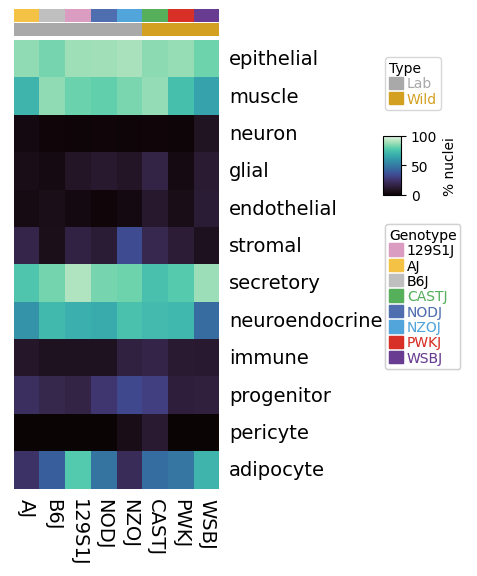

In [19]:
plt.figure(figsize=(2.75, 5.5), dpi = 100)

cm = pch.ClusterMapPlotter(data=plot_df.loc[:,df_col.index.tolist()],
                           show_rownames = True, 
                           show_colnames = True, 
                           cmap = "mako",
                           label = "% nuclei",
                           top_annotation=col_ha, 
                           row_cluster=False,
                           col_cluster=False,
                           vmin = 0,
                           vmax = 100,
                           yticklabels_kws={'labelsize': 14},
                           xticklabels_kws={'labelsize': 14} 
                          )

plt.savefig(f"../supp_fig5/general_celltype_sex_heatmap.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()

## Same per-tissue, subtype level but for sex

In [20]:
tissues = ['Heart','Liver','Adrenal','Gastrocnemius','Kidney','Liver',
           'CortexHippocampus','DiencephalonPituitary']

all_chisq_df = []
for tissue in tissues:
    chisq_sex_results = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/figures/subclustering_subtypes_final/{tissue}_sex_chisq_n_cells_per_genotype_each_geno_no_rep_filter_40_n_cells_filter.csv')
    all_chisq_df.append(chisq_sex_results)
df = pd.concat(all_chisq_df, ignore_index=True)

all_geno_chisq_df = df

In [21]:
summary = (
    all_geno_chisq_df
    .groupby(['tissue', 'subtype'])
    .agg(
        n_cells=('n_cells', 'sum'),
        total_n_cells=('total_n_cells', 'sum')
    )
    .reset_index()
)

summary['pct'] = (summary['n_cells'] / summary['total_n_cells']) * 100
summary['subtype_tissue'] = summary['subtype'] + '_' + summary['tissue']

subset = summary[summary['pct'] >= 0]
subset = subset['subtype_tissue'].tolist()


In [22]:
heatmap_df = (
    all_geno_chisq_df
    .groupby(['tissue', 'Sex', 'subtype'])
    .agg(
        n_cells=('n_cells', 'sum'),
        total_n_cells=('total_n_cells', 'sum')
    )
    .reset_index()
)

heatmap_df['pct'] = (heatmap_df['n_cells'] / heatmap_df['total_n_cells']) * 100
heatmap_df['subtype_tissue'] = heatmap_df['subtype'] + '_' + heatmap_df['tissue']
heatmap_df = heatmap_df[heatmap_df['subtype_tissue'].isin(subset)]


In [23]:
df_row = heatmap_df[['subtype_tissue', 'subtype', 'tissue']]
df_row = df_row.drop_duplicates()
df_row = df_row.set_index("subtype_tissue", drop=False)


In [24]:
plot_df = heatmap_df.pivot_table(index='subtype_tissue', columns='Sex', values='pct')
plot_df = plot_df.fillna(0)


In [25]:
df_col = pd.DataFrame({
    "Sex": plot_df.columns,
})
df_col = df_col.drop_duplicates()

Sex_categories = ['Female','Male']
df_col['Sex'] = pd.Categorical(df_col['Sex'], categories=Sex_categories, ordered=True)
df_col.sort_values(['Sex'], inplace=True)
df_col = df_col.set_index("Sex", drop=False)


sex_dict = {
    'Female': 'hotpink',
    'Male': 'dodgerblue',  
    
}

col_ha = pch.HeatmapAnnotation(Sex=pch.anno_simple(df_col['Sex'],colors=sex_dict),
                               verbose=1,
                               label_kws = {'visible': False},
                               axis=1)

left_ha = pch.HeatmapAnnotation(Tissue=pch.anno_simple(df_row['tissue'],colors=tissue_dict),vmin=0,
                                label_kws = {'visible': False},
                                plot_kws={'vmax': 100},
                                axis=0)


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol


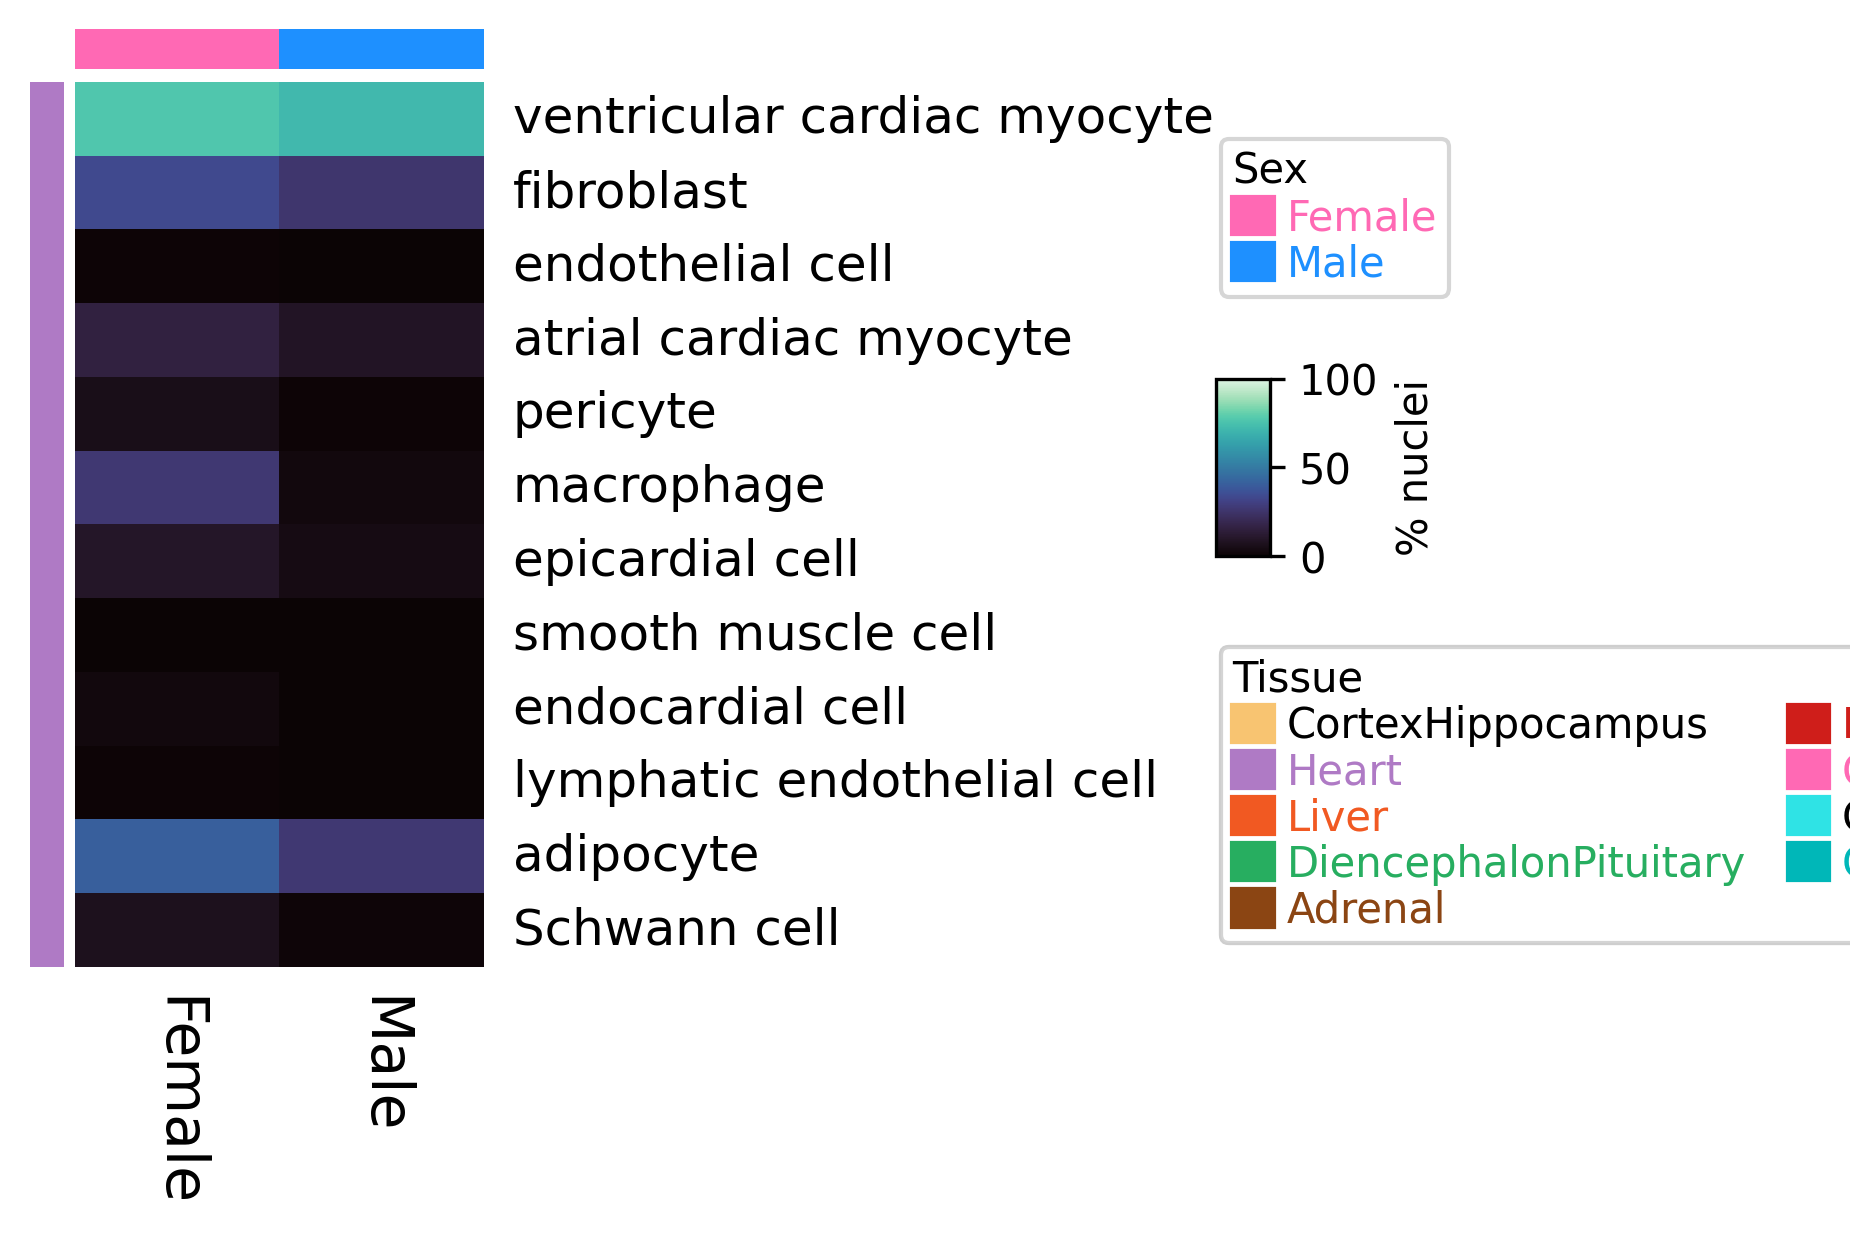

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol


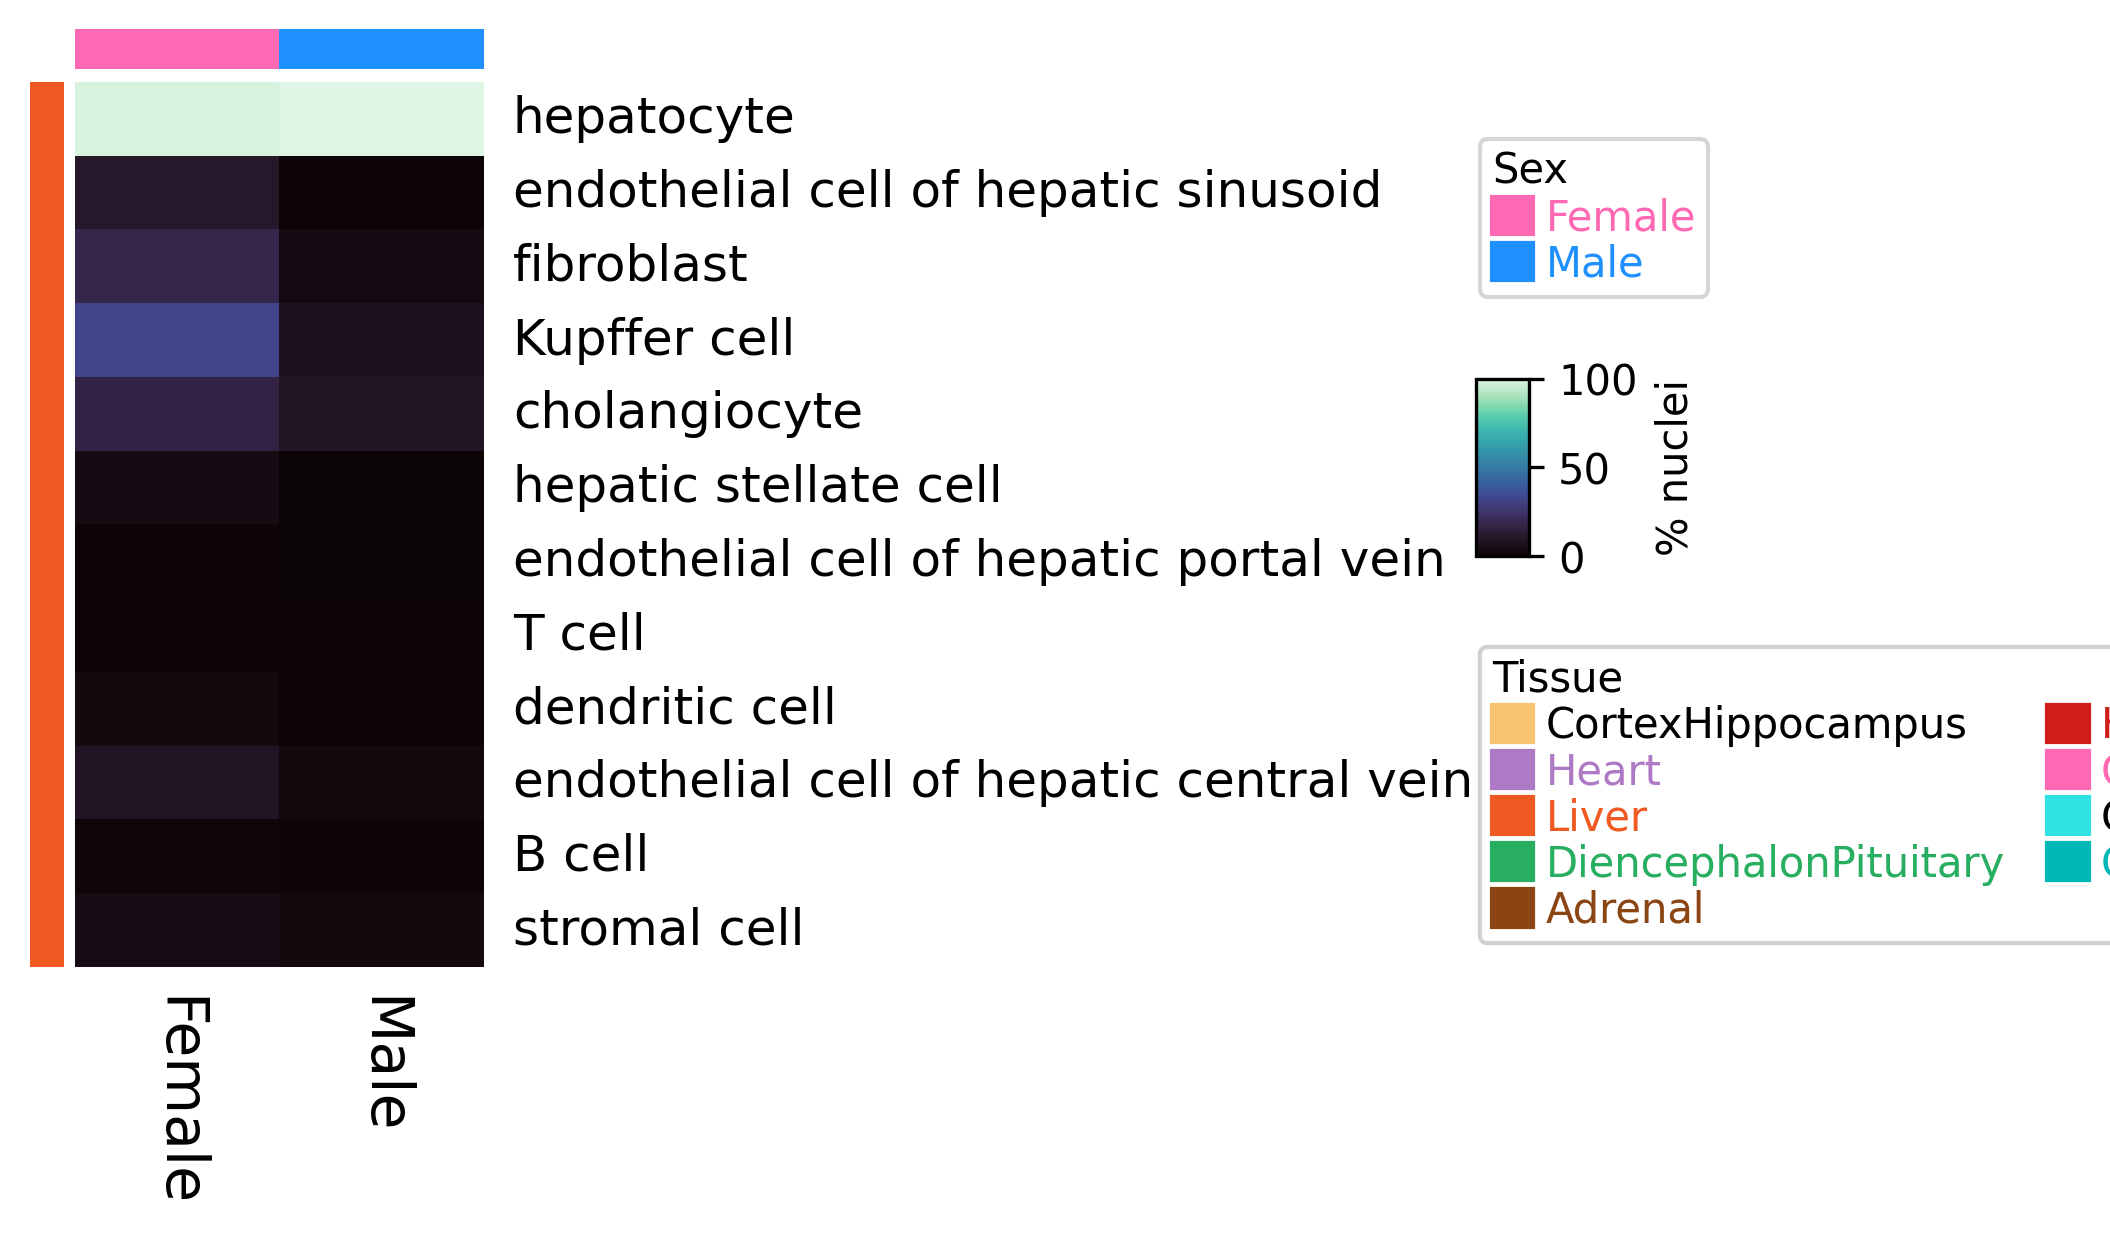

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


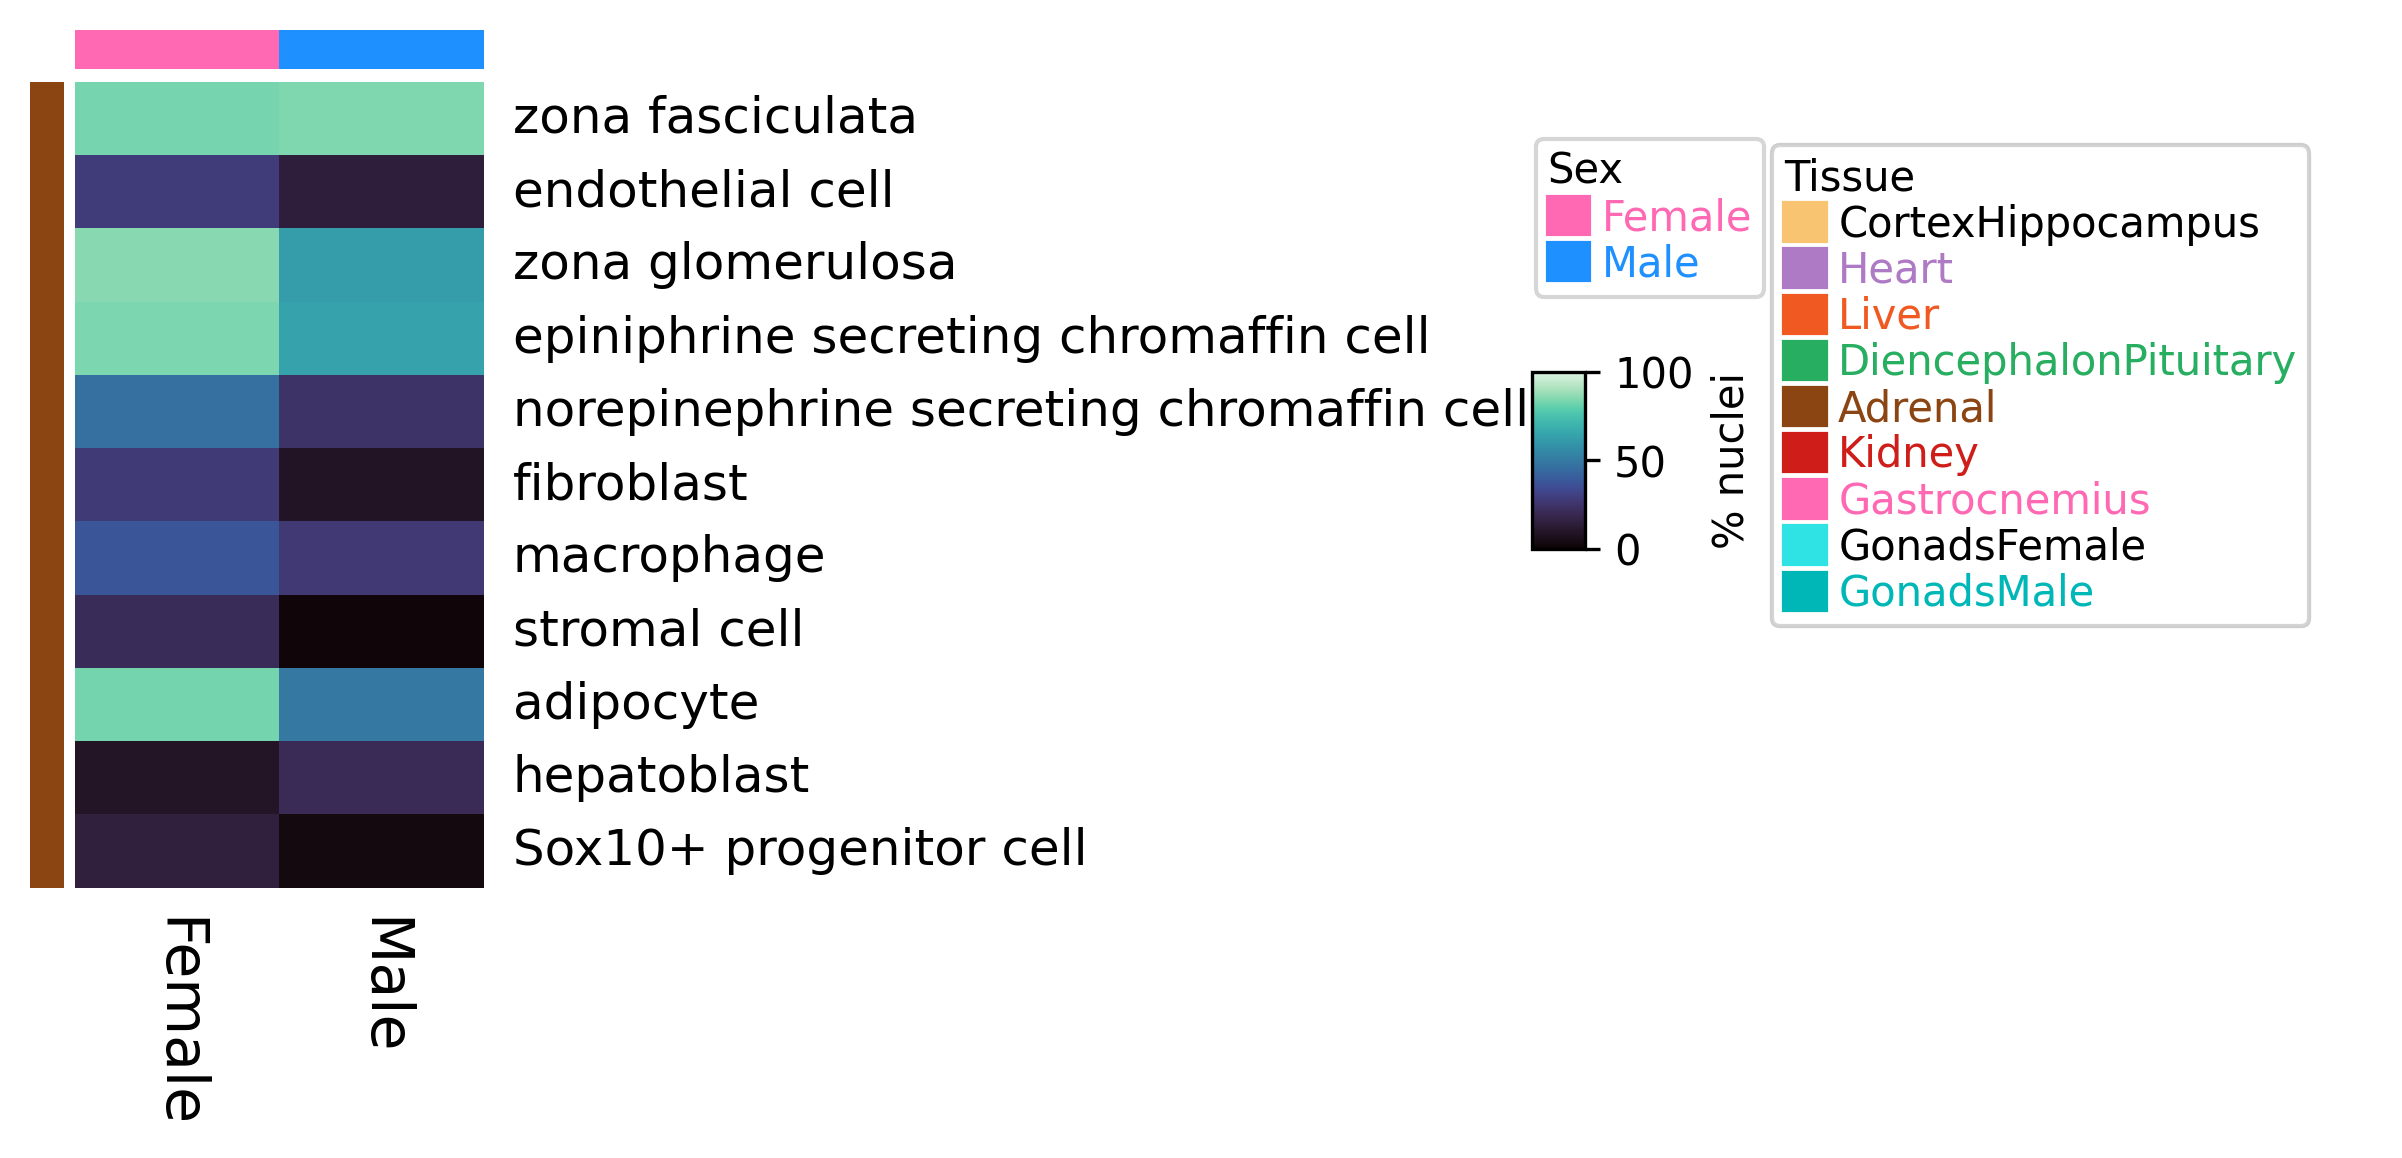

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm


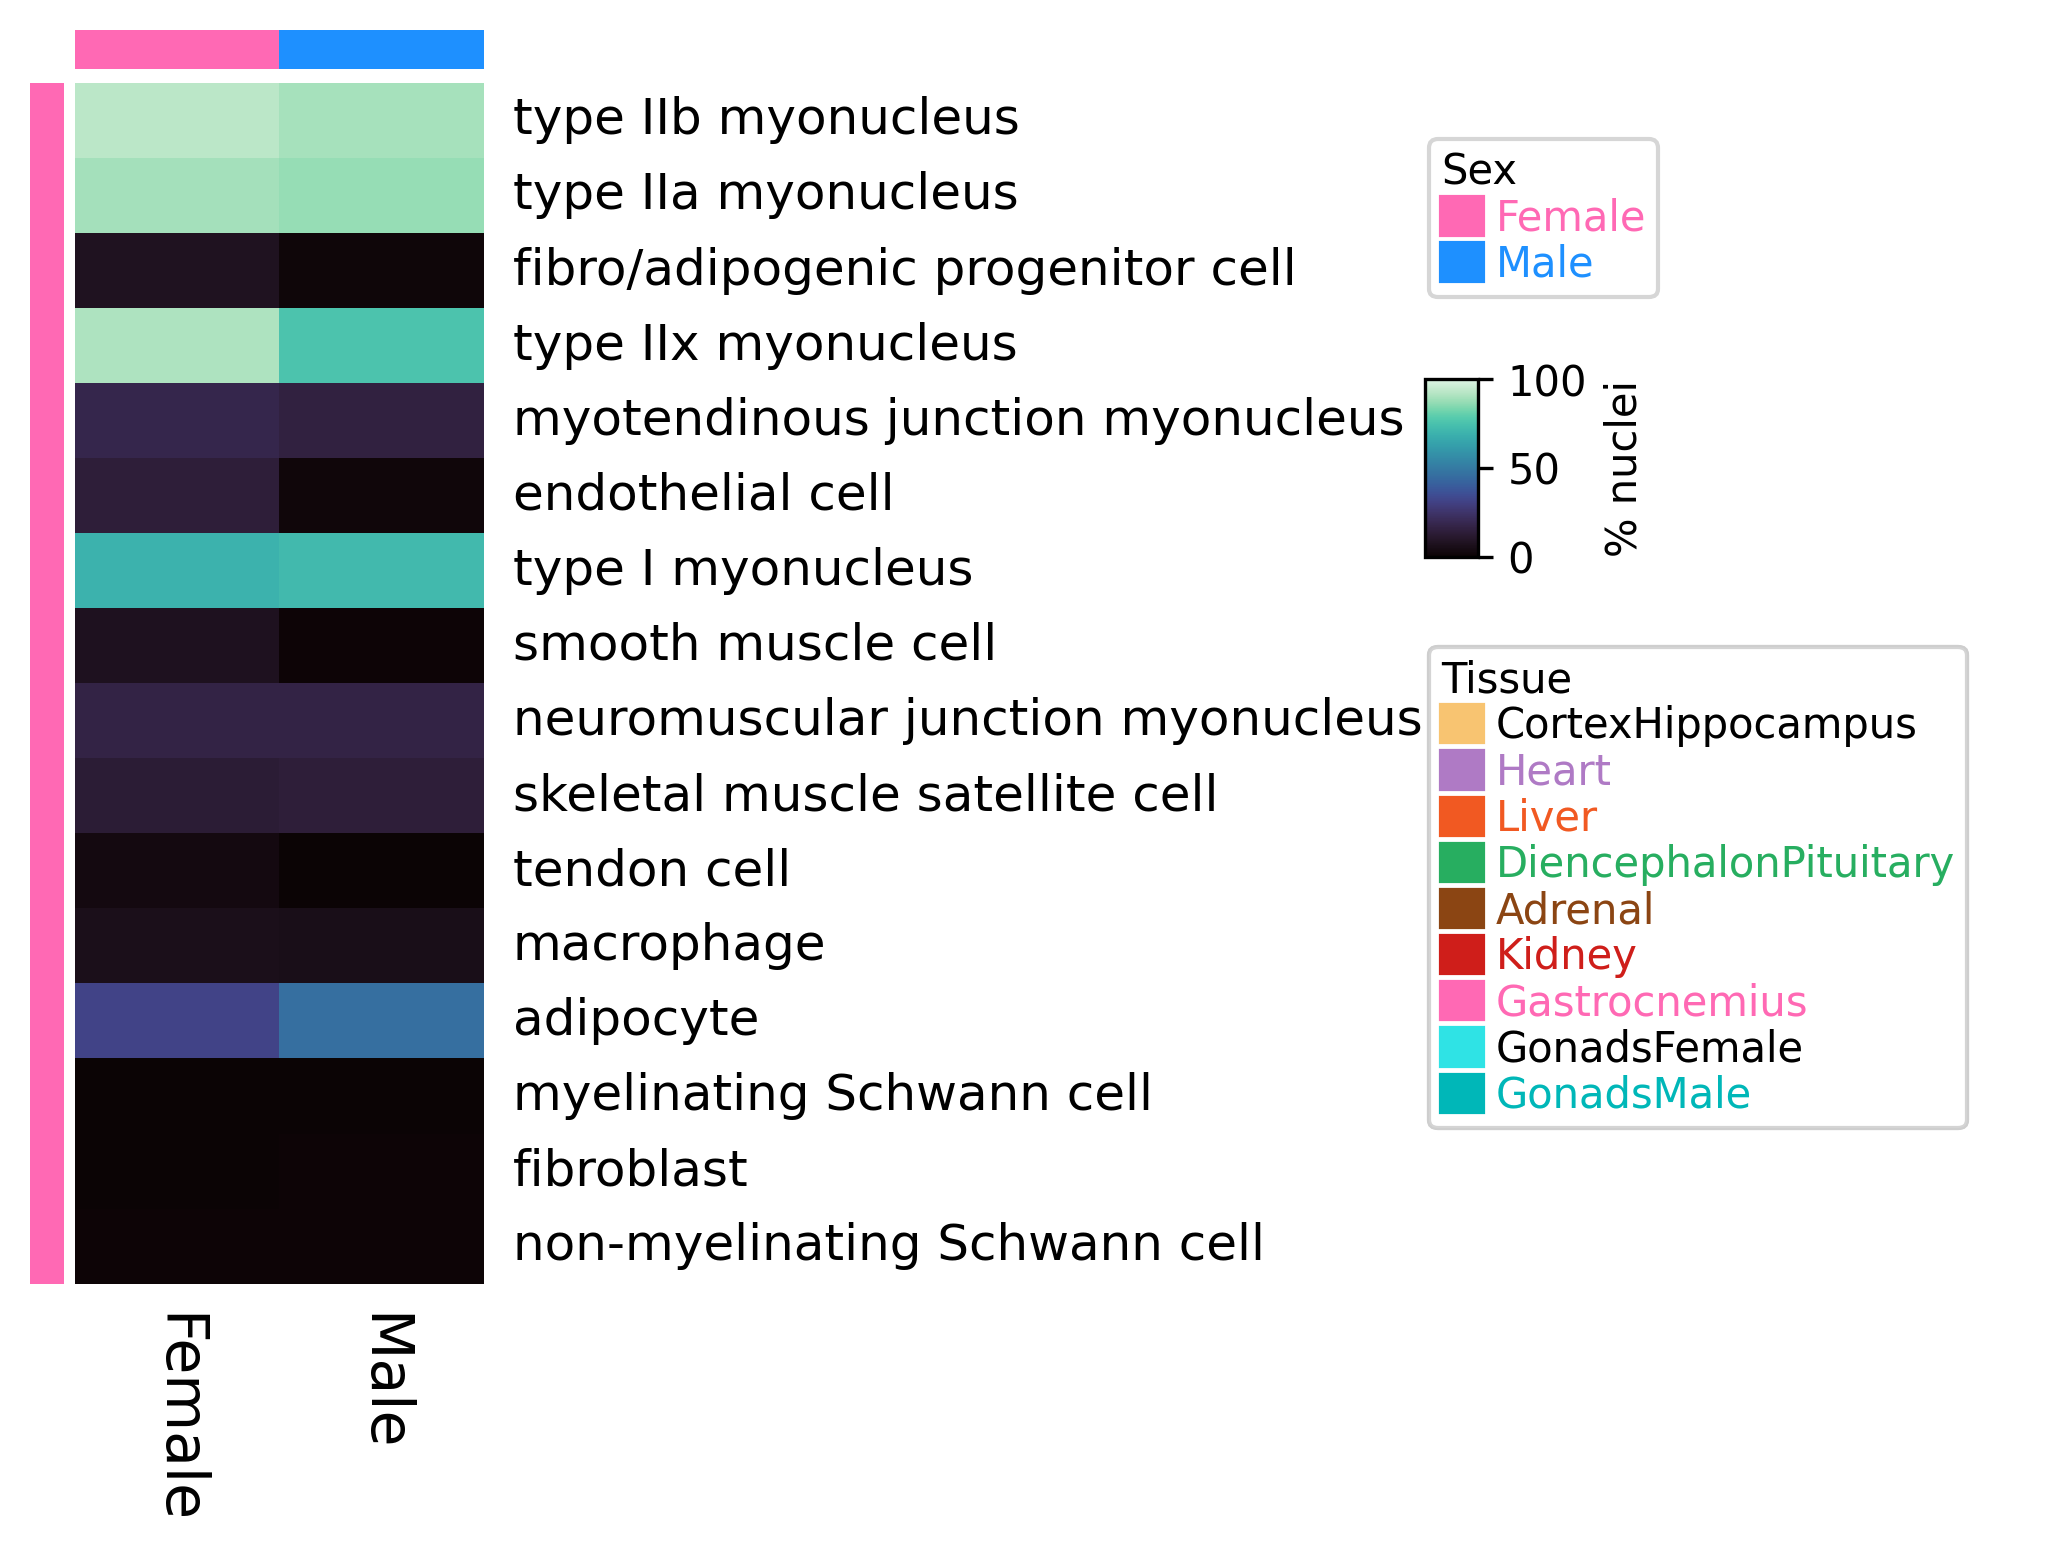

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm


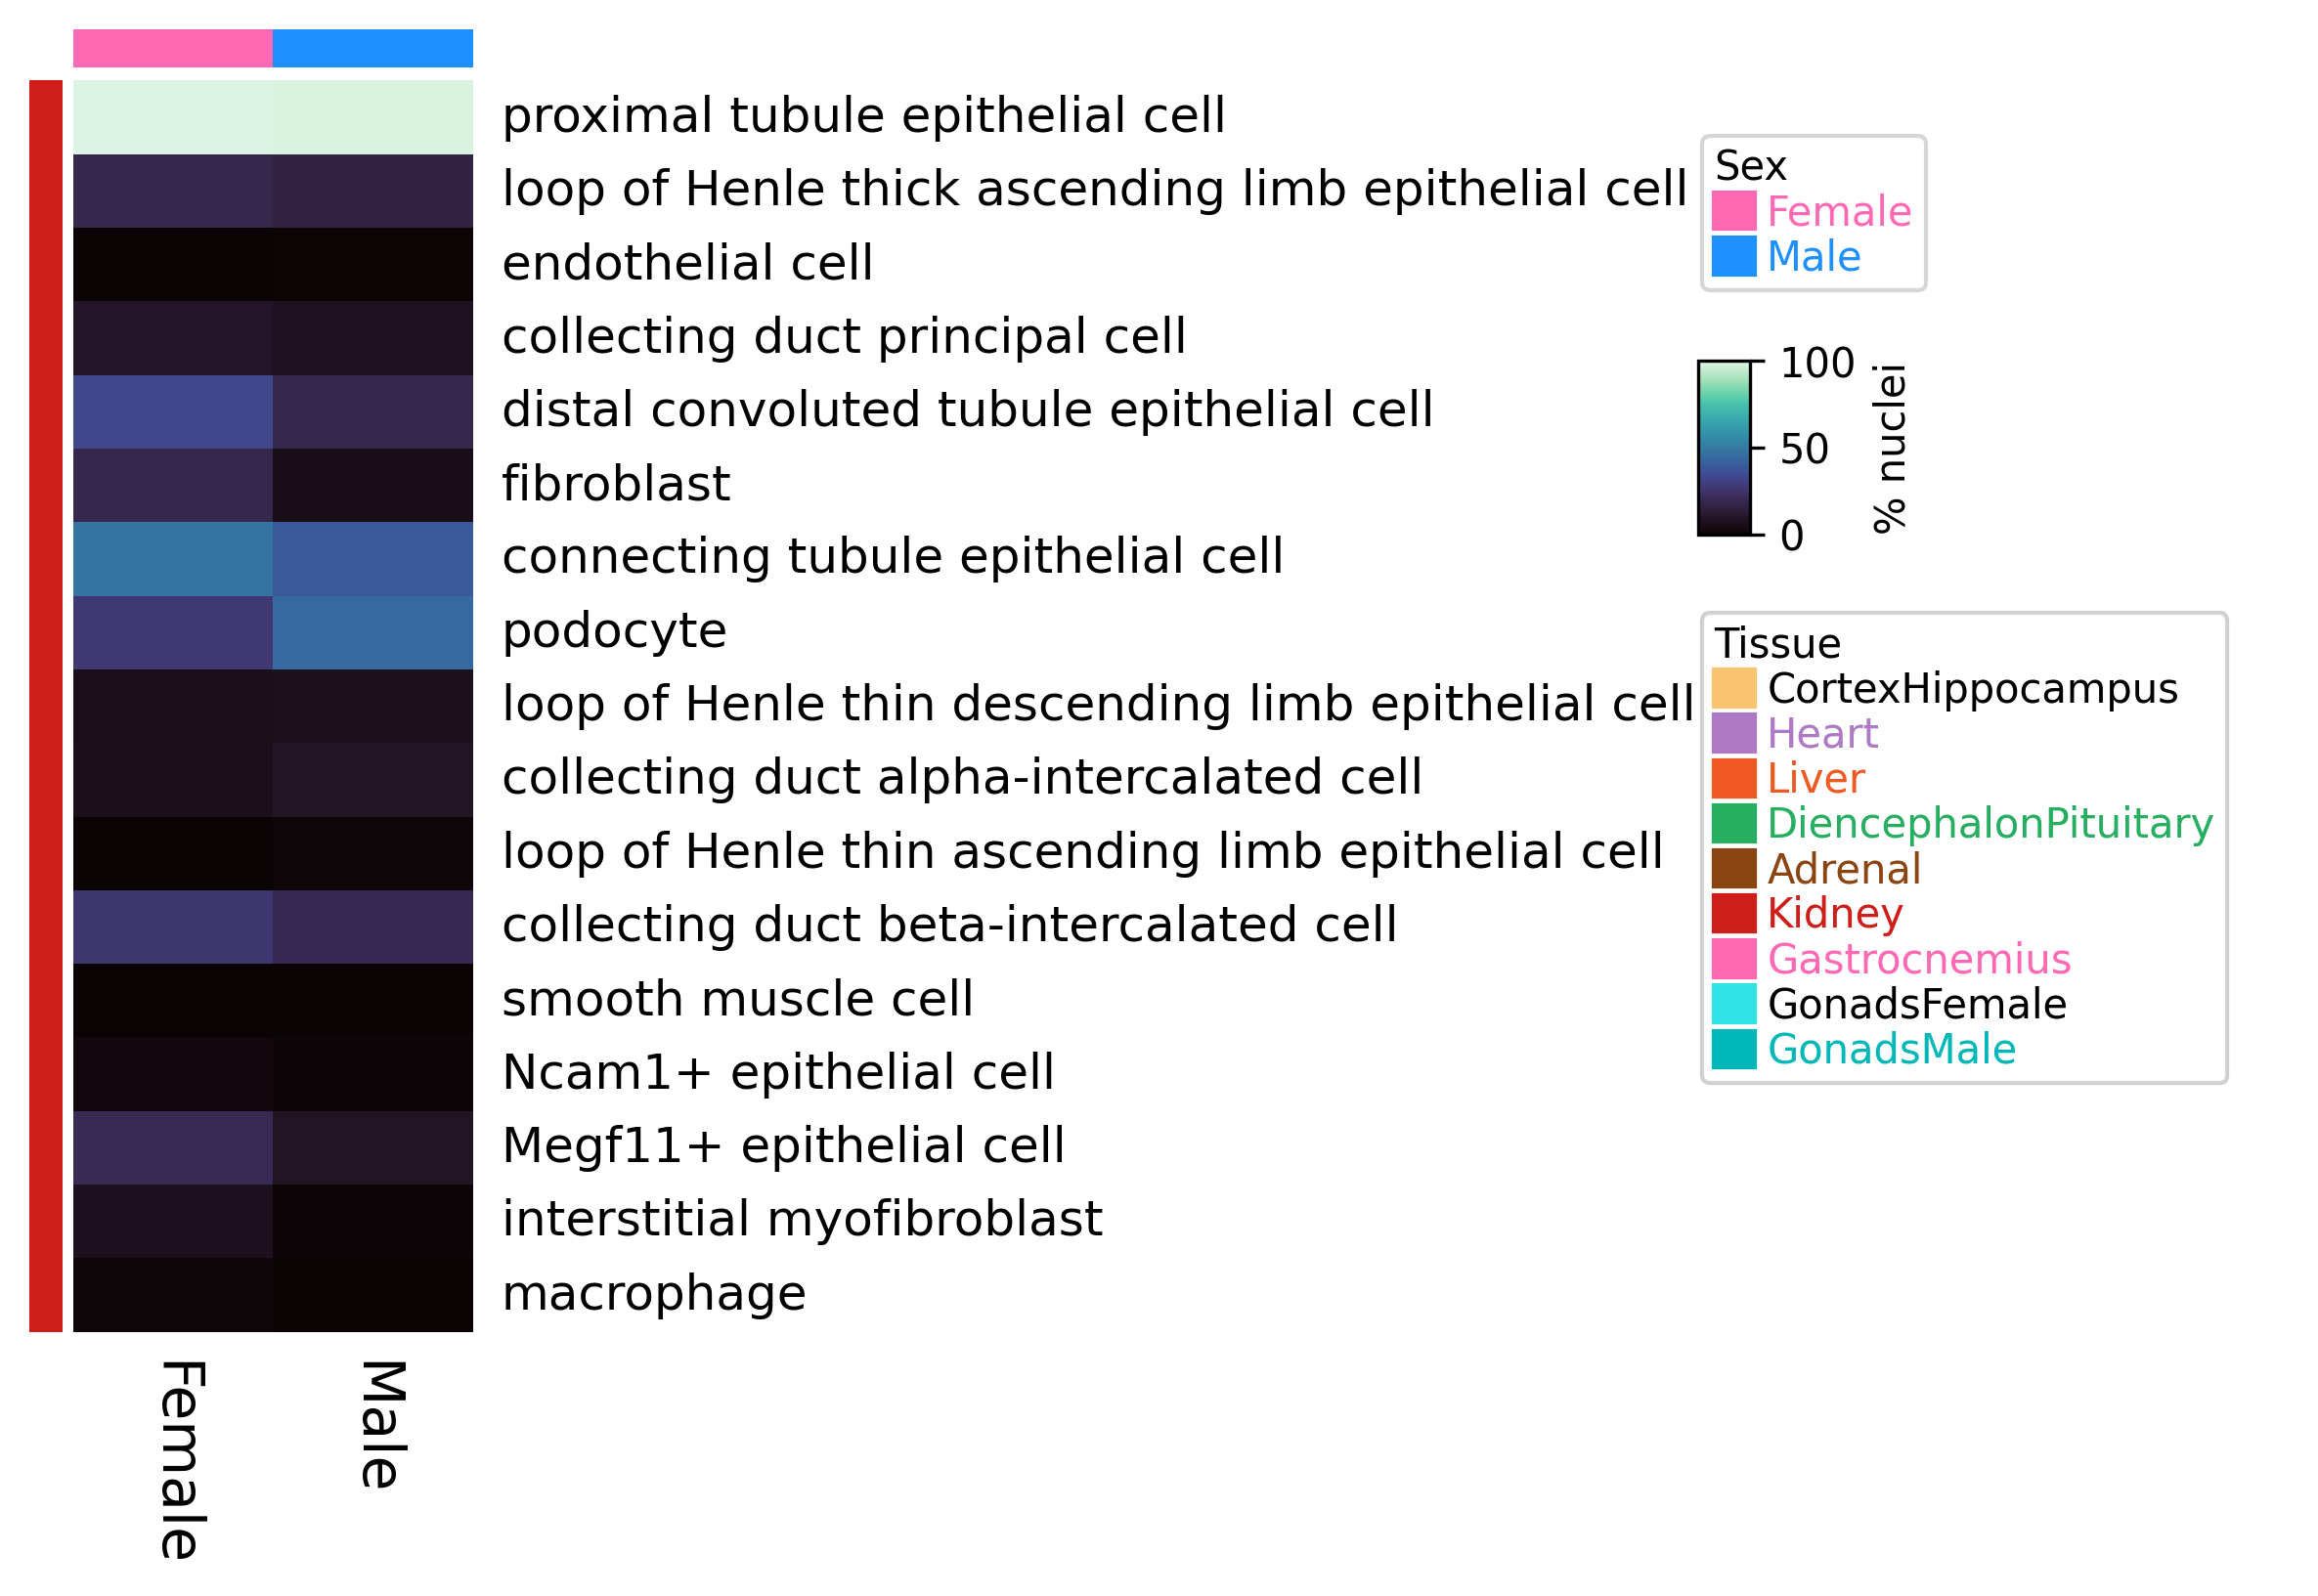

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm
Incresing ncol


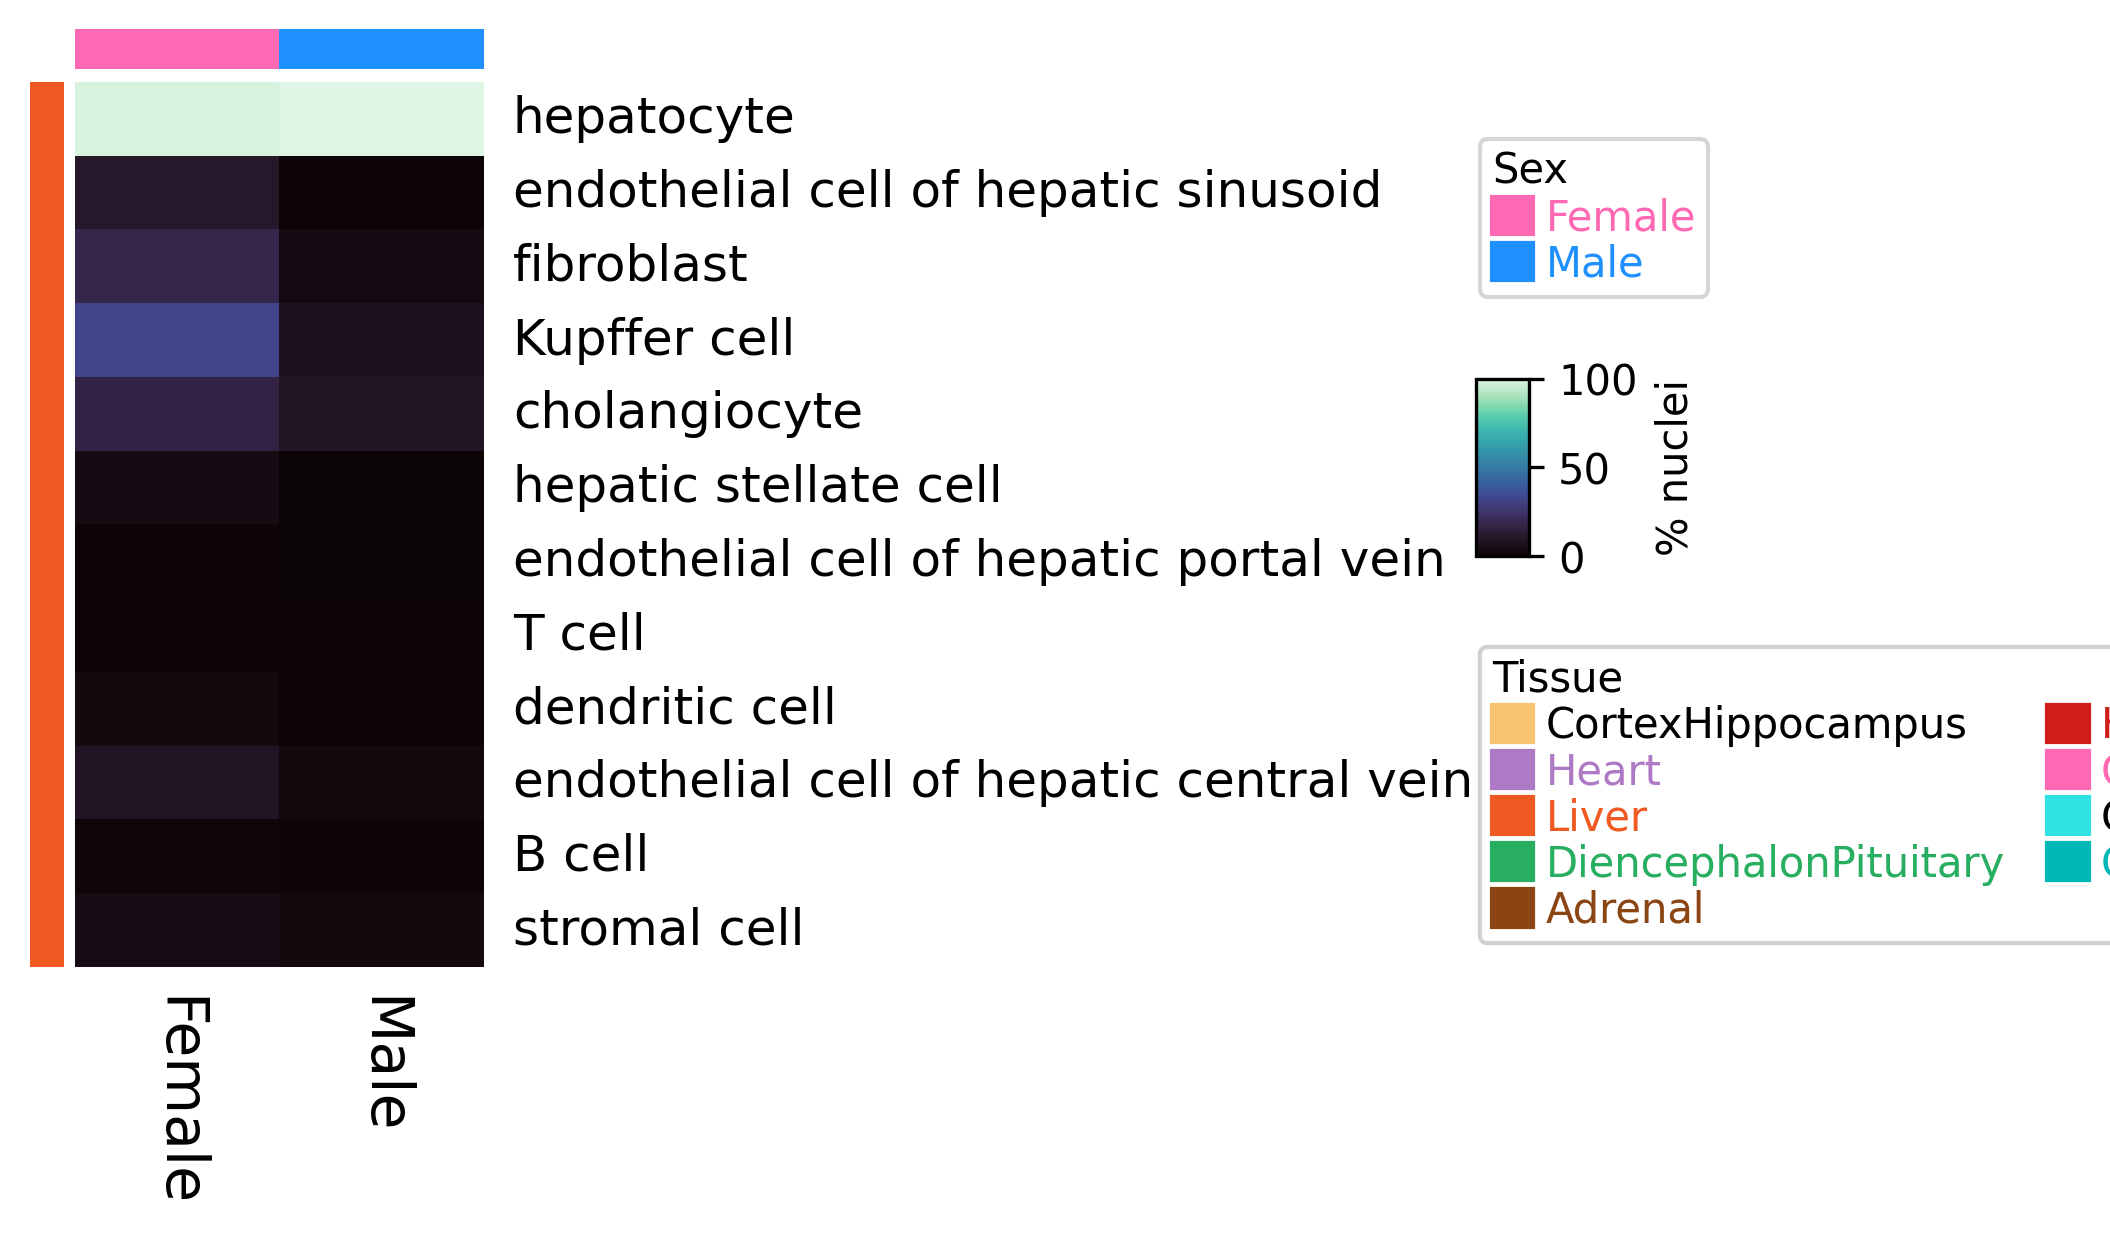

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm


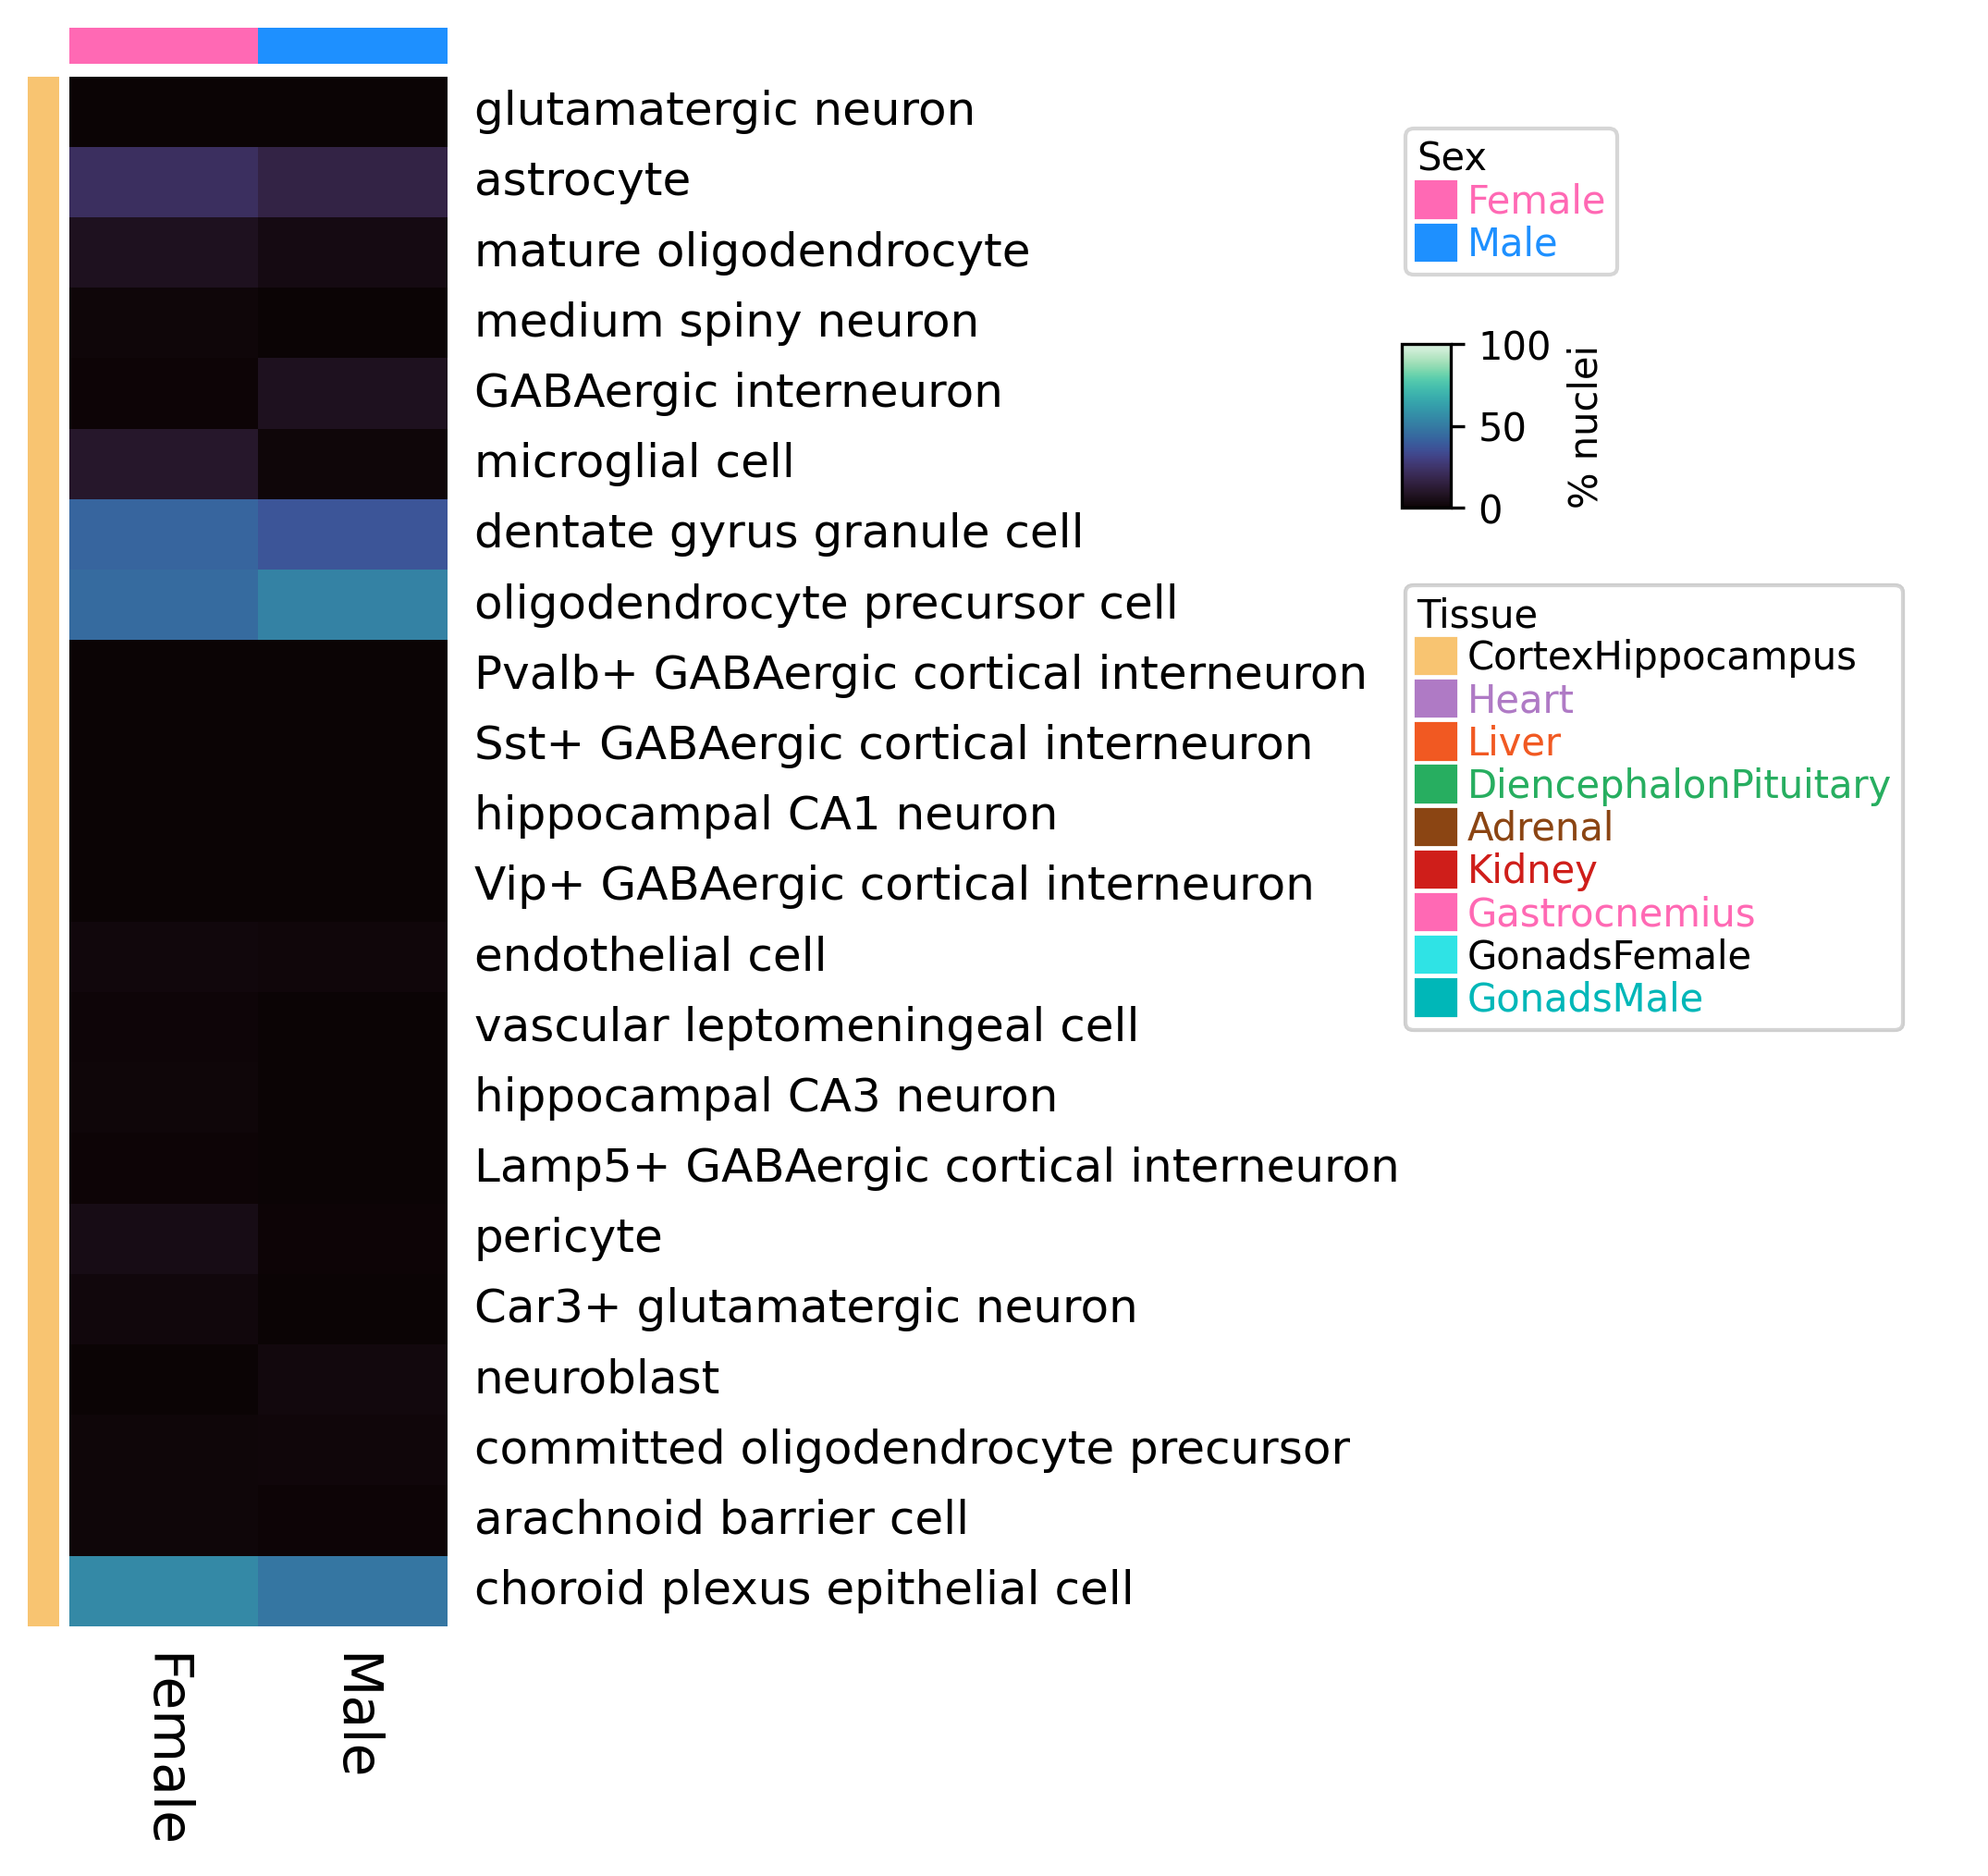

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 51.15416666666667 mm


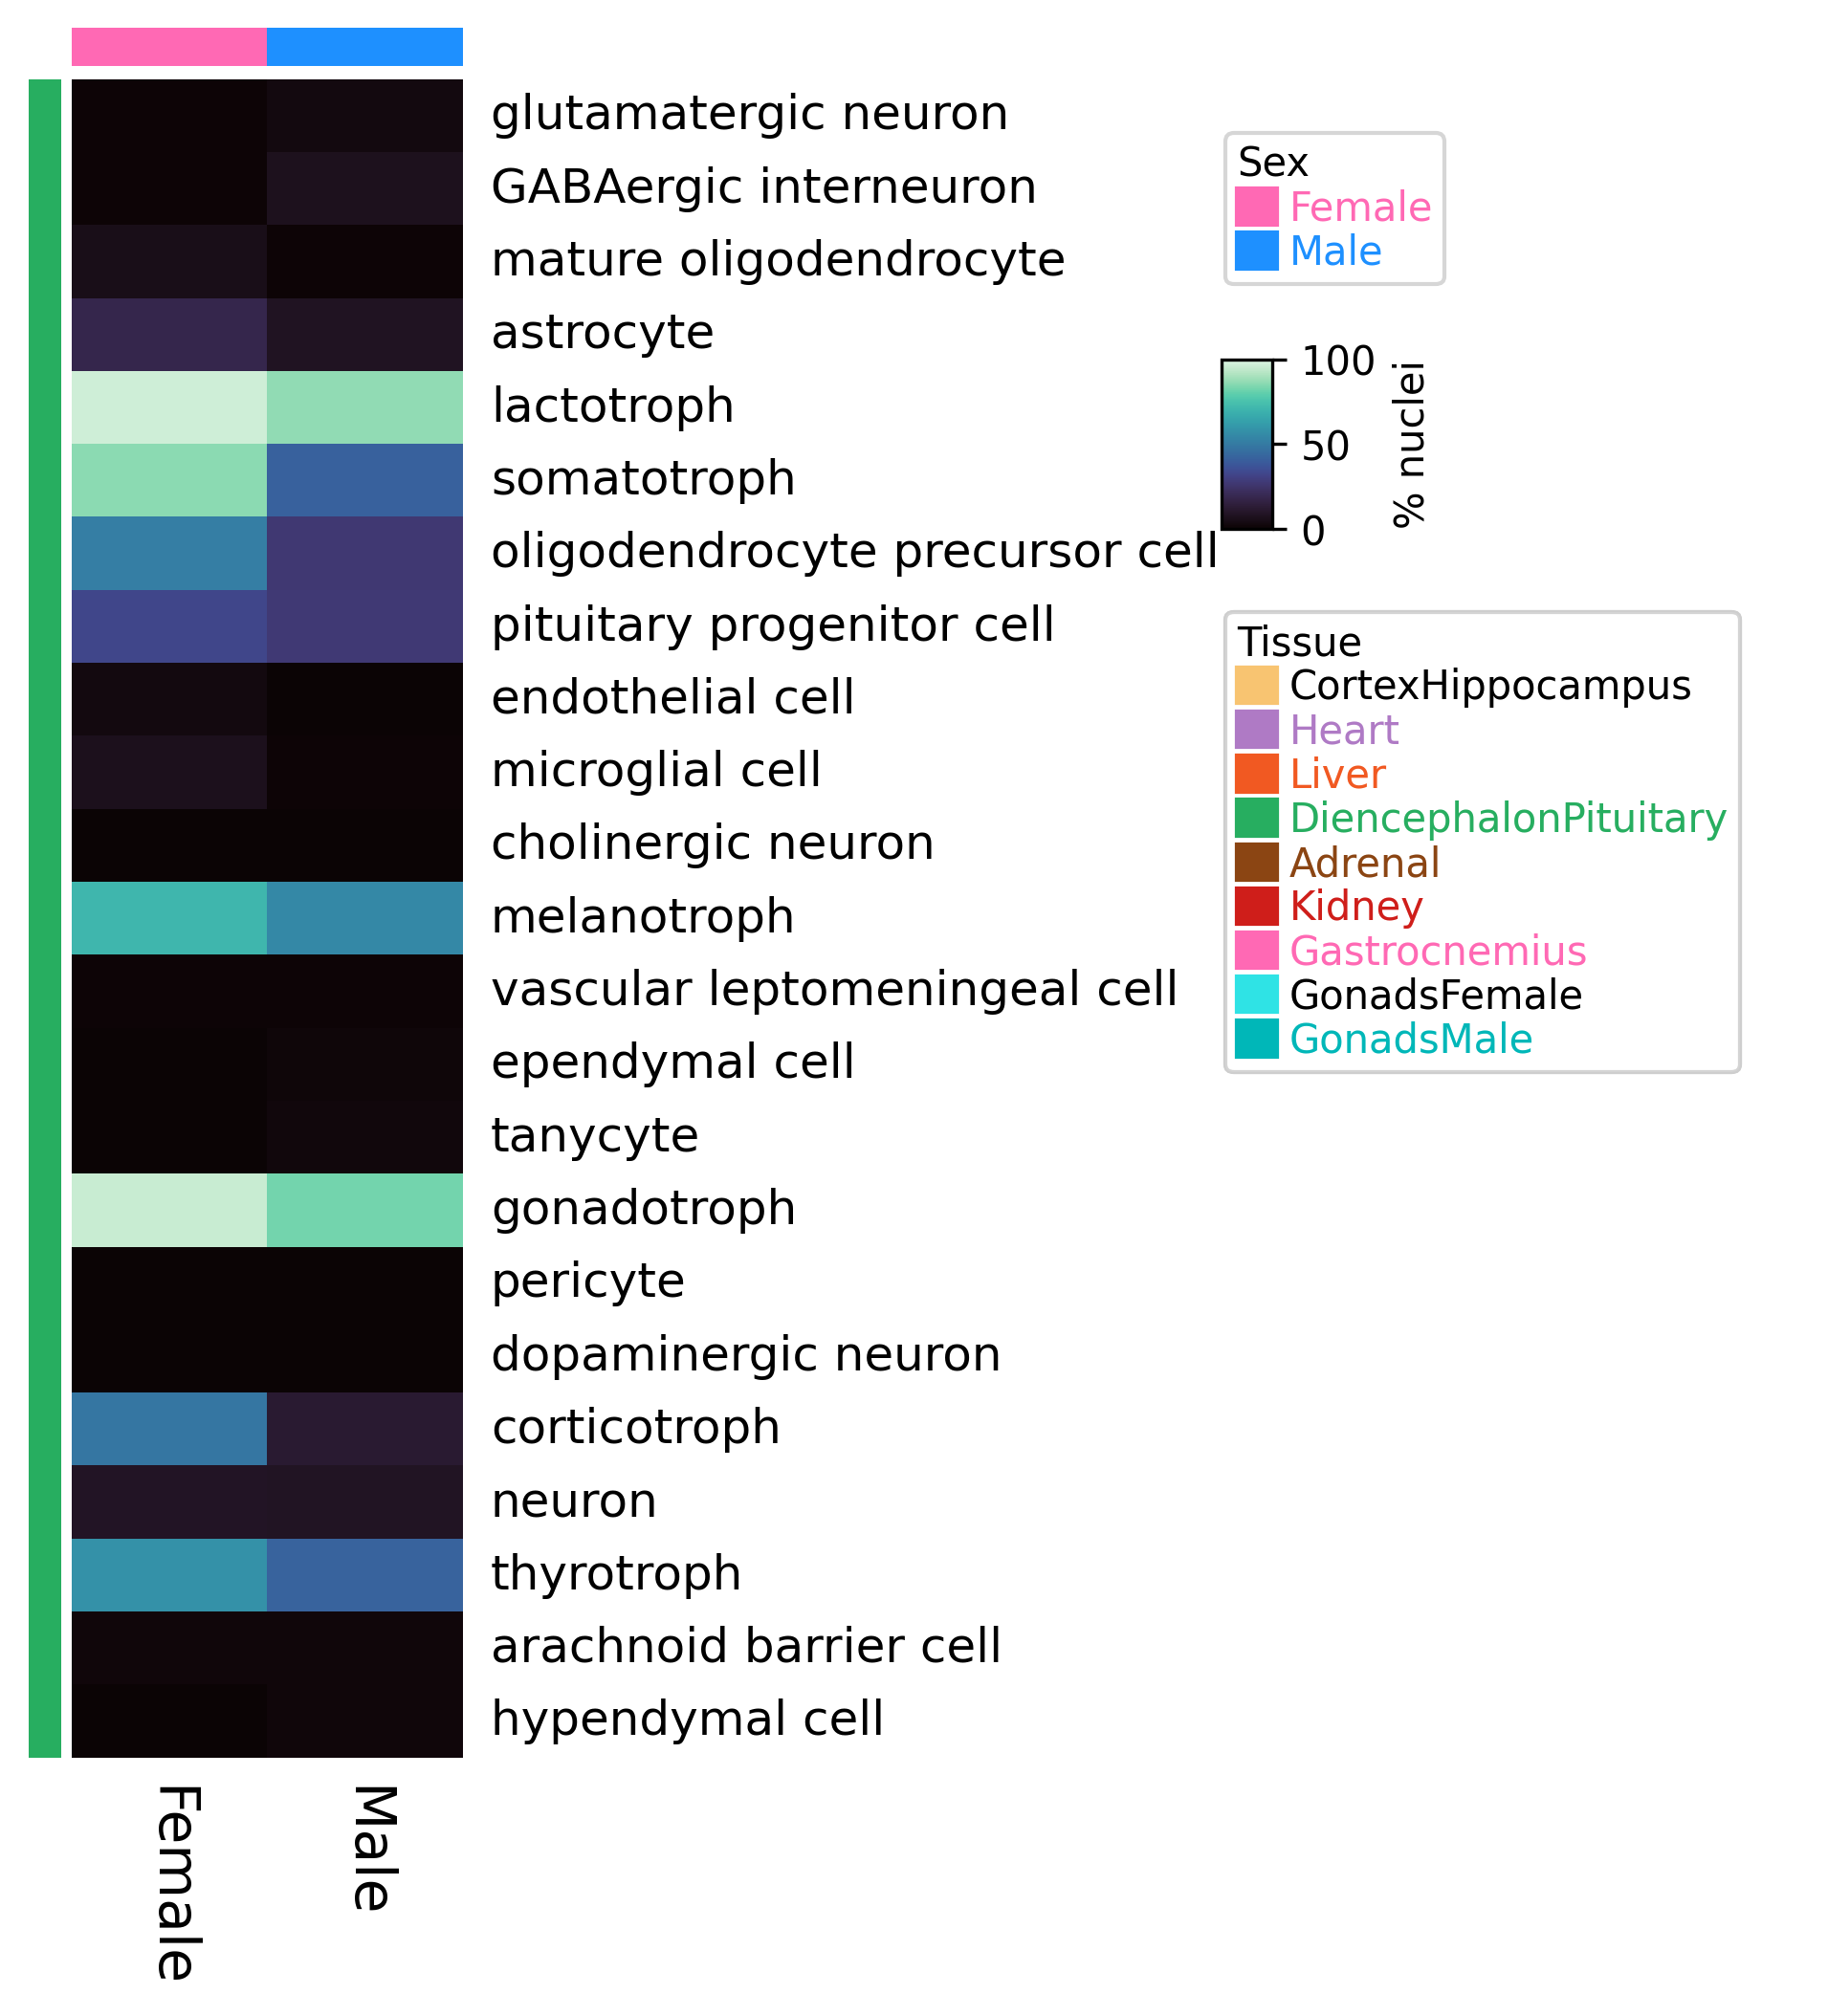

In [26]:
for tissue in tissues:
    heatmap_df_tissue = heatmap_df[heatmap_df['tissue'] == tissue].copy()

    # Create df_row with unique subtypes and total_n_cells for sorting
    df_row = (
        heatmap_df_tissue[['subtype', 'total_n_cells']]
        .drop_duplicates(subset=['subtype'])  # 1 row per subtype
        .sort_values('total_n_cells', ascending=False)  # biggest first
        .set_index('subtype', drop=False)
    )

    # Make sure Tissue annotation stays aligned
    df_row['tissue'] = tissue

    left_ha = pch.HeatmapAnnotation(
        Tissue=pch.anno_simple(df_row['tissue'], colors=tissue_dict),
        vmin=0,
        label_kws={'visible': False},
        plot_kws={'vmax': 100},
        axis=0
    )

    plot_df = heatmap_df_tissue.pivot_table(index='subtype', columns='Sex', values='pct').fillna(0)

    # Use sorted subtype order!
    plot_df = plot_df.loc[df_row.index.tolist(), df_col.index.tolist()]

    n_rows = plot_df.shape[0]
    height_per_row = 0.3
    base_height = 1.0
    fig_height = max(base_height, n_rows * height_per_row)

    plt.figure(figsize=(2, fig_height), dpi=300)

    cm = pch.ClusterMapPlotter(
        data=plot_df,
        show_rownames=True,
        show_colnames=True,
        cmap="mako",
        label="% nuclei",
        top_annotation=col_ha,
        left_annotation=left_ha,
        row_cluster=False,
        col_cluster=False,
        vmin=0,
        vmax=100,
        yticklabels_kws={'labelsize': 12},
        xticklabels_kws={'labelsize': 14}
    )

    plt.savefig(f"../supp_fig5/{tissue}_heatmap_sex.png", bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()
